In [4]:
# =============================================================================
# NOTEBOOK 03 — TOPIC MODELING
# =============================================================================

# =============================================================================
# 0. Imports et chargement
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
import seaborn as sns
from pathlib import Path
import re
import string
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Charger le DataFrame enrichi
df = pd.read_pickle("../data/df_explore.pkl")
print(f"DataFrame chargé : {len(df)} lignes, {len(df.columns)} colonnes")
print(f"Années : {sorted(df['year'].unique())}")
print(f"Familles politiques : {df['parti_famille'].value_counts().to_dict()}")

# =============================================================================
# 1. Configuration esthétique (même style que notebook 02)
# =============================================================================
import os
import urllib.request

FONT_DIR = os.path.expanduser("~/.fonts")
os.makedirs(FONT_DIR, exist_ok=True)

fonts_to_download = {
    "Playfair Display": "https://github.com/google/fonts/raw/main/ofl/playfairdisplay/PlayfairDisplay%5Bwght%5D.ttf",
    "Source Sans 3": "https://github.com/google/fonts/raw/main/ofl/sourcesans3/SourceSans3%5Bwght%5D.ttf",
}
for name, url in fonts_to_download.items():
    path = os.path.join(FONT_DIR, f"{name}.ttf")
    if not os.path.exists(path):
        urllib.request.urlretrieve(url, path)
font_manager.fontManager.addfont(os.path.join(FONT_DIR, "Playfair Display.ttf"))
font_manager.fontManager.addfont(os.path.join(FONT_DIR, "Source Sans 3.ttf"))

FONT_TITLE = 'Playfair Display'
FONT_BODY = 'Source Sans 3'

PARTY_COLORS = {
    'PCF': '#D4626E', 'PS': '#E8919A', 'Radicaux': '#F0B87E',
    'Ecologistes': '#8CBF8C', 'UDF': '#7EADD4', 'RPR': '#5B8DB8',
    'FN': '#2E4A62', 'Non mentionné': '#C4BFB6', 'Autre': '#A89F96',
}
YEAR_COLORS = {'1981': '#D4626E', '1988': '#7EADD4', '1993': '#5B8DB8'}
BG_COLOR = '#FAF7F2'
TEXT_COLOR = '#2C2824'
GRID_COLOR = '#E8E4DD'

plt.rcParams.update({
    'figure.facecolor': BG_COLOR, 'axes.facecolor': BG_COLOR,
    'axes.edgecolor': GRID_COLOR, 'axes.labelcolor': TEXT_COLOR,
    'text.color': TEXT_COLOR, 'xtick.color': TEXT_COLOR, 'ytick.color': TEXT_COLOR,
    'grid.color': GRID_COLOR, 'grid.alpha': 0.5, 'font.family': FONT_BODY,
    'font.size': 11, 'axes.titlesize': 16, 'axes.labelsize': 12,
    'figure.dpi': 150, 'axes.spines.top': False, 'axes.spines.right': False,
})

print("Style configuré ✓")

# =============================================================================
# 2. Préparation du texte pour le Topic Modeling
# =============================================================================
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Stopwords étendus pour les professions de foi
STOPWORDS_FR = [
    'le', 'la', 'les', 'de', 'des', 'du', 'un', 'une', 'et', 'en', 'à',
    'au', 'aux', 'ce', 'ces', 'que', 'qui', 'dans', 'pour', 'par', 'sur',
    'avec', 'son', 'ses', 'sa', 'se', 'ne', 'pas', 'nous', 'vous', 'ils',
    'est', 'sont', 'ont', 'été', 'être', 'avoir', 'fait', 'faire', 'plus',
    'tout', 'tous', 'toute', 'toutes', 'mais', 'ou', 'où', 'si', 'leur',
    'leurs', 'elle', 'elles', 'il', 'je', 'me', 'mon', 'ma', 'mes',
    'notre', 'nos', 'votre', 'vos', 'même', 'aussi', 'bien', 'peut',
    'cette', 'cet', 'dont', 'comme', 'sans', 'entre', 'très', 'après',
    'avant', 'autres', 'autre', 'encore', 'quand', 'car', 'donc',
    'sera', 'non', 'oui', 'puis', 'ici', 'là', 'ya', 'ça', 'cela',
    'ceci', 'on', 'ny', 'na', 'ni', 'peu', 'chaque', 'ces', 'sous',
    'depuis', 'eux', 'lui', 'celle', 'ceux', 'celui', 'quelques',
    'tant', 'ainsi', 'vers', 'chez', 'contre', 'dès', 'trop',
    'lors', 'déjà', 'soit', 'car', 'afin', 'tel', 'telle',
    # Mots très fréquents dans les professions de foi (bruit)
    'circonscription', 'candidat', 'candidate', 'élections', 'législatives',
    'république', 'française', 'france', 'département', 'juin', 'mars',
    'tour', 'scrutin', 'vote', 'voter', 'électeurs', 'électeur',
    'profession', 'foi', 'premier', 'première', 'second', 'seconde',
    'nom', 'prénom', 'année', 'années', 'ans', 'deux', 'trois',
    'faut', 'doit', 'peuvent', 'doivent', 'être', 'avoir',
    'falloir', 'pouvoir', 'devoir', 'aller', 'dire', 'voir',
    'vouloir', 'savoir', 'mettre', 'prendre', 'donner',
]

# Vérifier que text_clean existe
if 'text_clean' not in df.columns:
    def clean_text(text):
        if not isinstance(text, str):
            return ""
        text = text.lower()
        text = text.replace('\n', ' ').replace('\r', ' ')
        text = text.translate(str.maketrans('', '', string.punctuation))
        text = re.sub(r'\d+', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    df['text_clean'] = df['text'].apply(clean_text)

# Filtrer les textes trop courts
df_topic = df[df['text_clean'].str.len() > 100].copy()
print(f"Documents retenus pour le topic modeling : {len(df_topic)} / {len(df)}")

# Filtrer les documents majoritairement en allemand
def is_french(text):
    if not isinstance(text, str):
        return False
    german_words = ['die', 'der', 'und', 'für', 'den', 'sie', 'das', 'ist', 'von']
    words = text.lower().split()
    if len(words) == 0:
        return False
    german_count = sum(1 for w in words if w in german_words)
    return german_count / len(words) < 0.05

mask_french = df_topic['text_clean'].apply(is_french)
print(f"Documents en français : {mask_french.sum()} / {len(df_topic)}")
print(f"Documents filtrés (allemand) : {(~mask_french).sum()}")
df_topic = df_topic[mask_french].copy()

# Stopwords enrichis — ajouter les mots politiques génériques qui polluent
EXTRA_STOPS = [
    'cest', 'quil', 'quils', 'dune', 'dun', 'jai', 'lassemblée',
    'nationale', 'national', 'suis', 'nest', 'naura', 'quon',
]
STOPWORDS_FR = STOPWORDS_FR + EXTRA_STOPS



# =============================================================================
# 3. Méthode 1 — LDA (Latent Dirichlet Allocation)
# =============================================================================
from sklearn.decomposition import LatentDirichletAllocation

# Vectorisation avec CountVectorizer (LDA attend des comptes, pas du TF-IDF)
count_vectorizer = CountVectorizer(
    max_features=5000,
    min_df=10,
    max_df=0.7,
    stop_words=STOPWORDS_FR,
    ngram_range=(1, 2)  # unigrammes + bigrammes
)

count_matrix = count_vectorizer.fit_transform(df_topic['text_clean'])
feature_names = count_vectorizer.get_feature_names_out()
print(f"Matrice documents-termes : {count_matrix.shape}")

# Entraîner LDA avec différents nombres de topics pour comparaison
N_TOPICS = 12  # nombre de topics à extraire

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=30,
    learning_method='online',
    random_state=42,
    n_jobs=-1
)

lda_topics = lda.fit_transform(count_matrix)
print(f"LDA entraîné : {N_TOPICS} topics")
print(f"Perplexité : {lda.perplexity(count_matrix):.1f}")
print(f"Log-likelihood : {lda.score(count_matrix):.1f}")

# =============================================================================
# 4. Afficher les topics LDA
# =============================================================================

def get_topic_words(model, feature_names, n_words=15):
    """Extraire les mots les plus importants de chaque topic."""
    topics = {}
    for idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        topics[idx] = top_words
    return topics

topic_words = get_topic_words(lda, feature_names)

print("\n=== Topics LDA ===\n")
for topic_id, words in topic_words.items():
    print(f"Topic {topic_id:2d} : {', '.join(words[:10])}")

# Nommer les topics manuellement 
# Juste en dessous il y a un disctionnaire, il faut que je le remplsse après avoir vu les mots de chaque topic
TOPIC_NAMES = {i: f"Topic {i}" for i in range(N_TOPICS)}
# Exemple : TOPIC_NAMES = {0: "Économie", 1: "Éducation", 2: "Sécurité", ...}
print("code executé")


DataFrame chargé : 12746 lignes, 51 colonnes
Années : ['1981', '1988', '1993']
Familles politiques : {'Non mentionné': 3035, 'Autre': 1949, 'RPR': 1803, 'PCF': 1765, 'PS': 1482, 'FN': 1241, 'Ecologistes': 1202, 'UDF': 254, 'Radicaux': 15}
Style configuré ✓
Documents retenus pour le topic modeling : 12744 / 12746
Documents en français : 12419 / 12744
Documents filtrés (allemand) : 325
Matrice documents-termes : (12419, 5000)
LDA entraîné : 12 topics
Perplexité : 1265.4
Log-likelihood : -24626066.6

=== Topics LDA ===

Topic  0 : nature, animaux, nature animaux, nouveaux, rassemblement nature, rassemblement, ecologistes, lhomme, ecologistes rassemblement, marseille
Topic  1 : majorité, député, conseiller, maire, président, politique, général, suppléant, socialiste, confiance
Topic  2 : gauche, droite, communiste, parti, politique, parti communiste, communistes, candidats, travailleurs, forces
Topic  3 : politique, travail, pays, vie, chômage, temps, entreprises, sociale, société, dévelop

In [7]:
TOPIC_NAMES = {
    0: "Écologie / protection animale",
    1: "Notabilité locale / mandat",
    2: "Clivage gauche-droite / PCF",
    3: "Économie, emploi, société",
    4: "Lutte sociale / défense des salaires",
    5: "Droite populiste / immigration",
    6: "FN / programme populaire",
    7: "Extrême-gauche / Lutte ouvrière",
    8: "Petits commerçants / classes moyennes",
    9: "Écologie / Verts",
    10: "Parti de la Loi Naturelle",
    11: "RPR-UDF / Union de la droite",
}

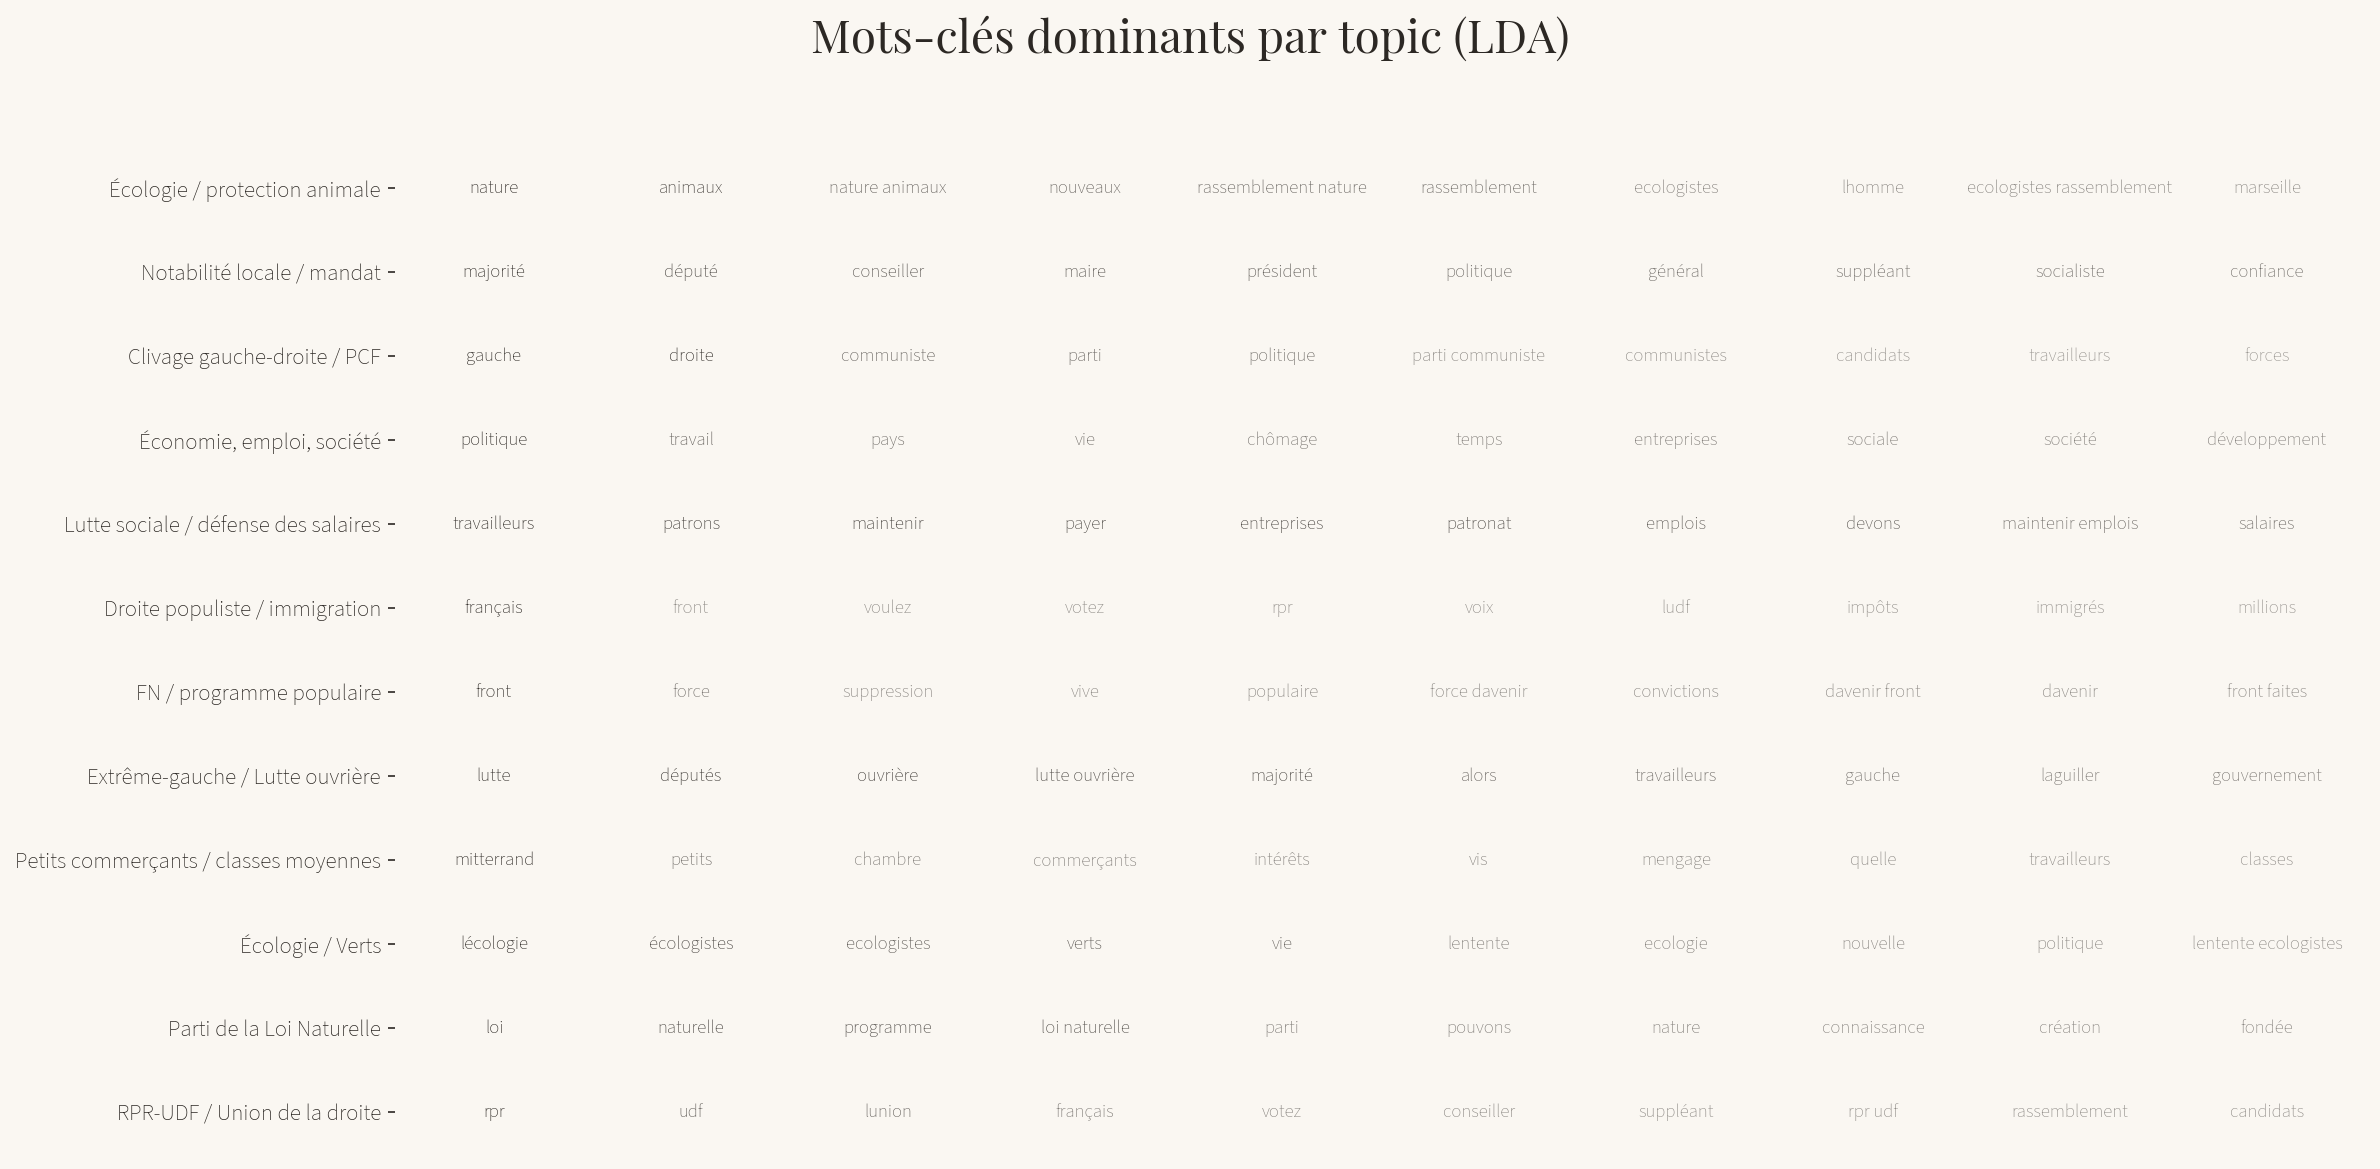


=== Distribution des topics dominants ===
topic_dominant
0      466
1     6711
2     1299
3     1701
4      236
5      581
6      522
8       57
9      461
10      97
11     288
Name: count, dtype: int64


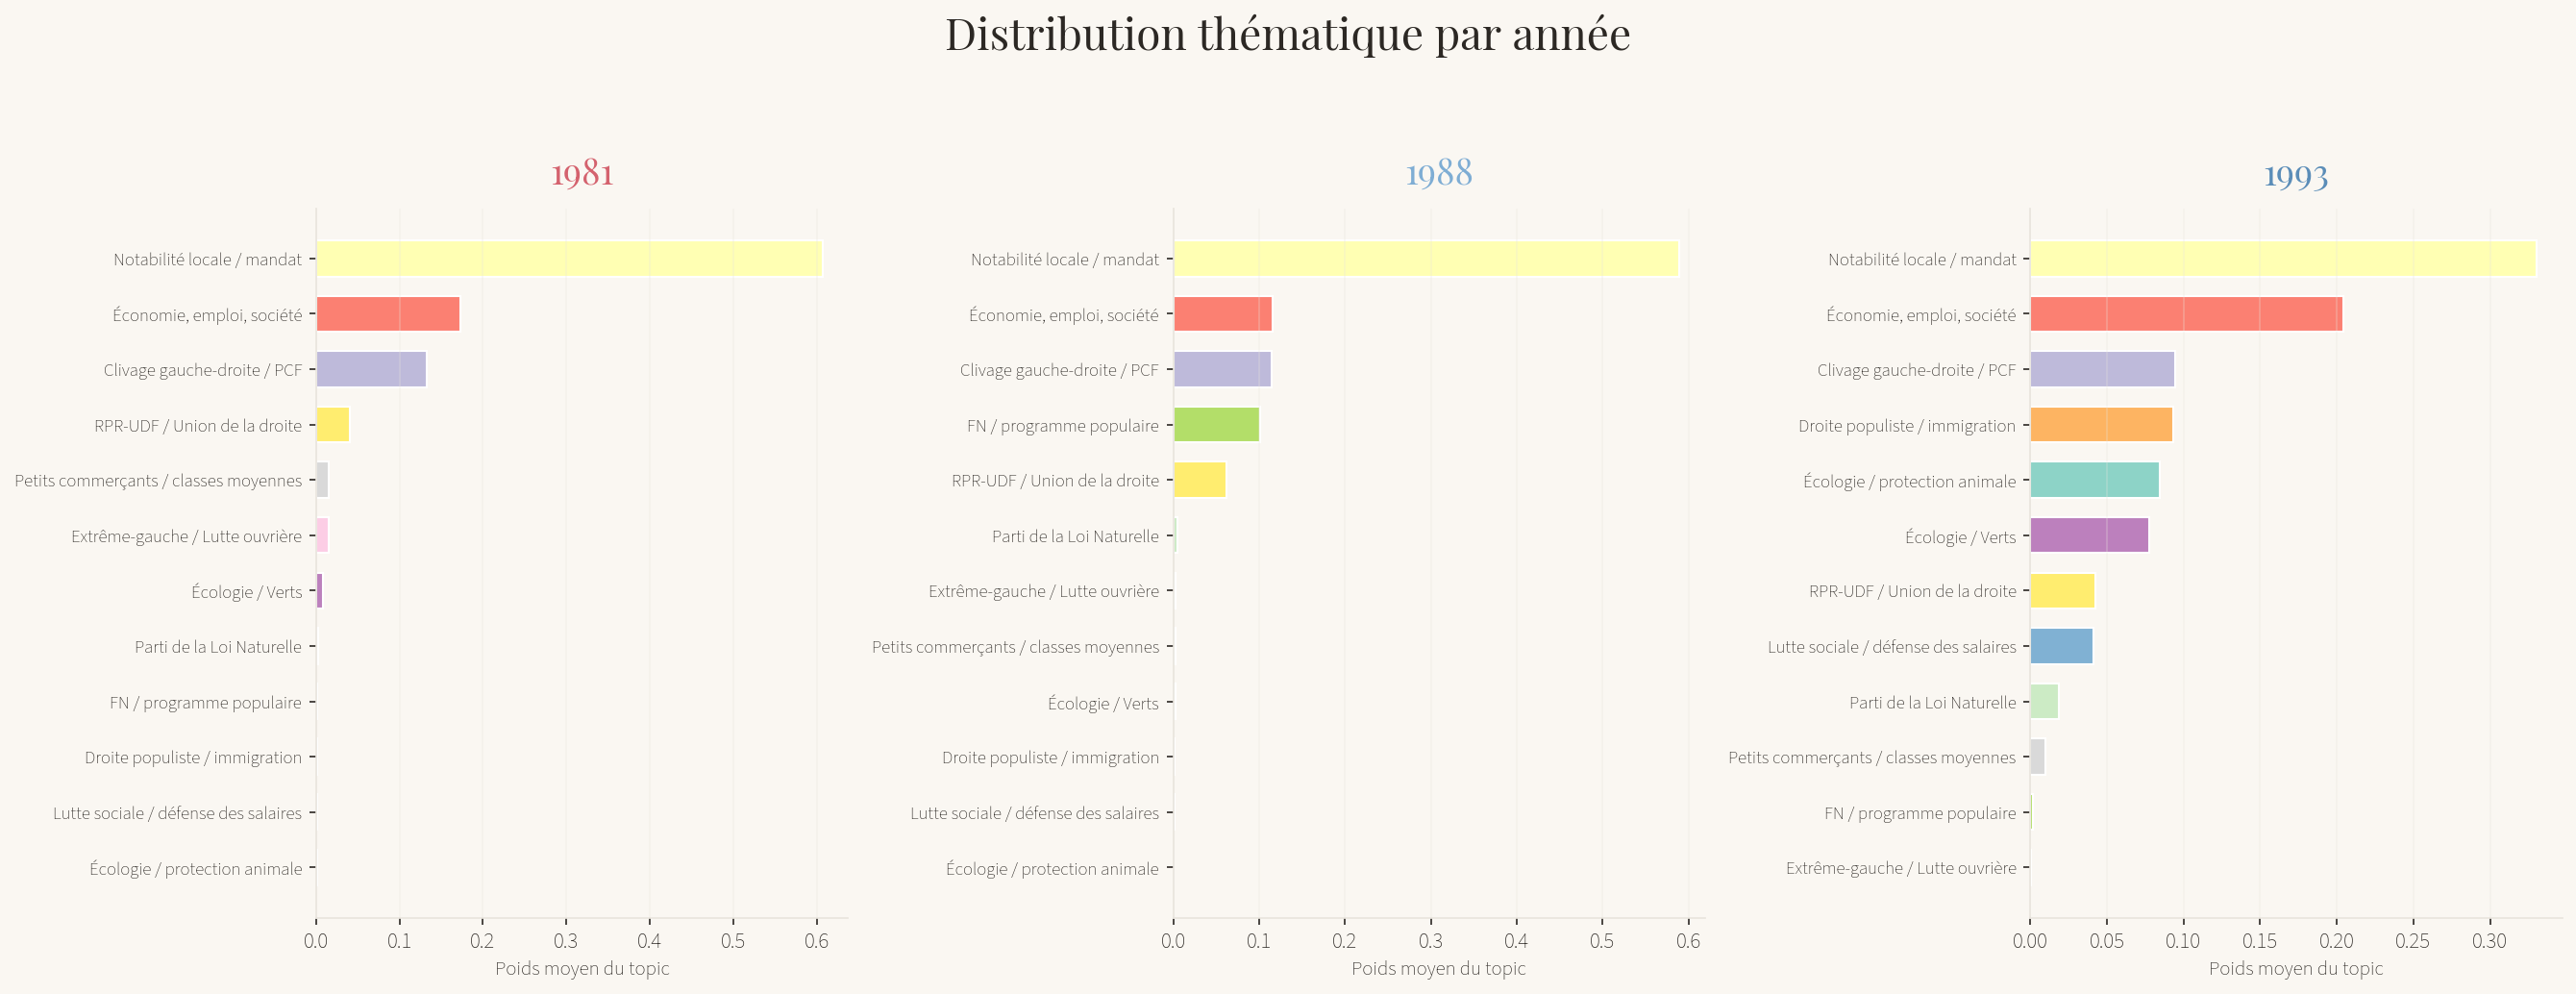

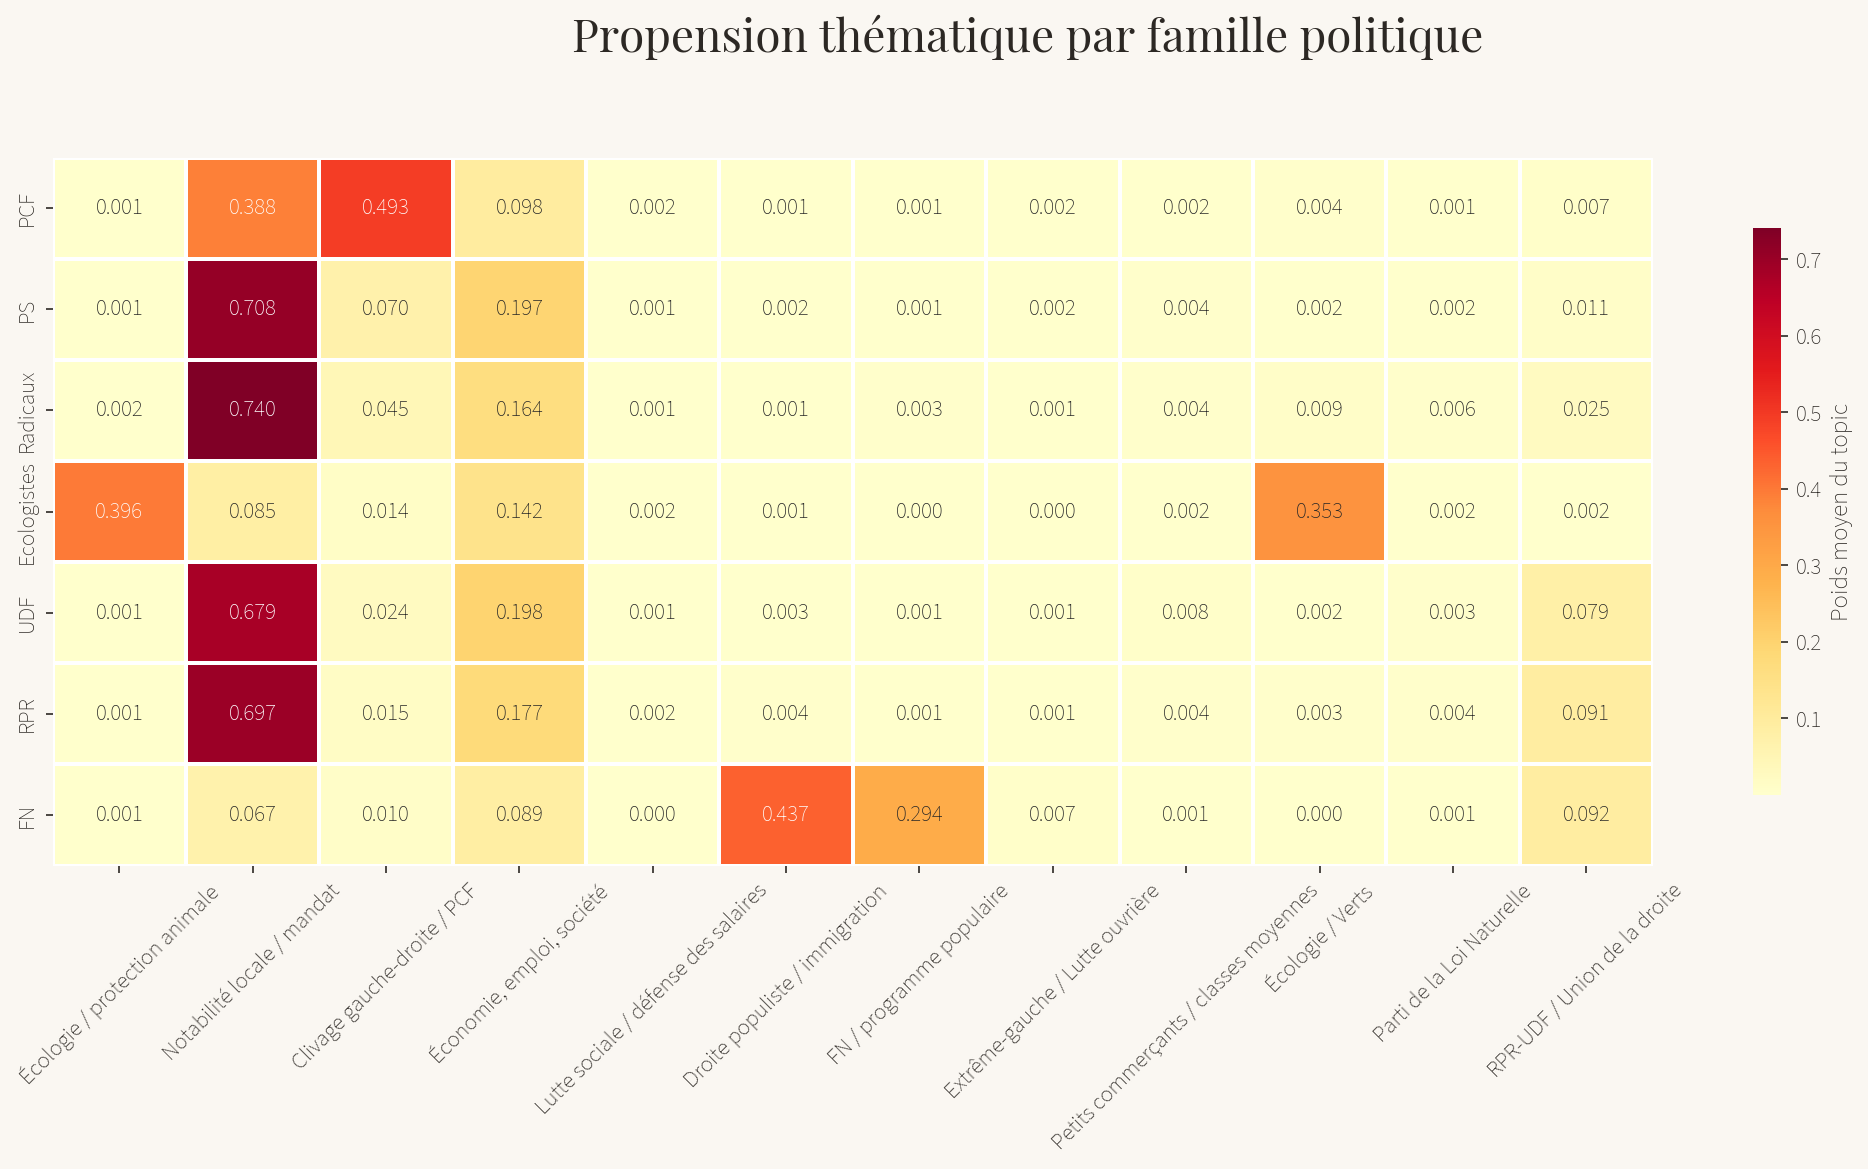

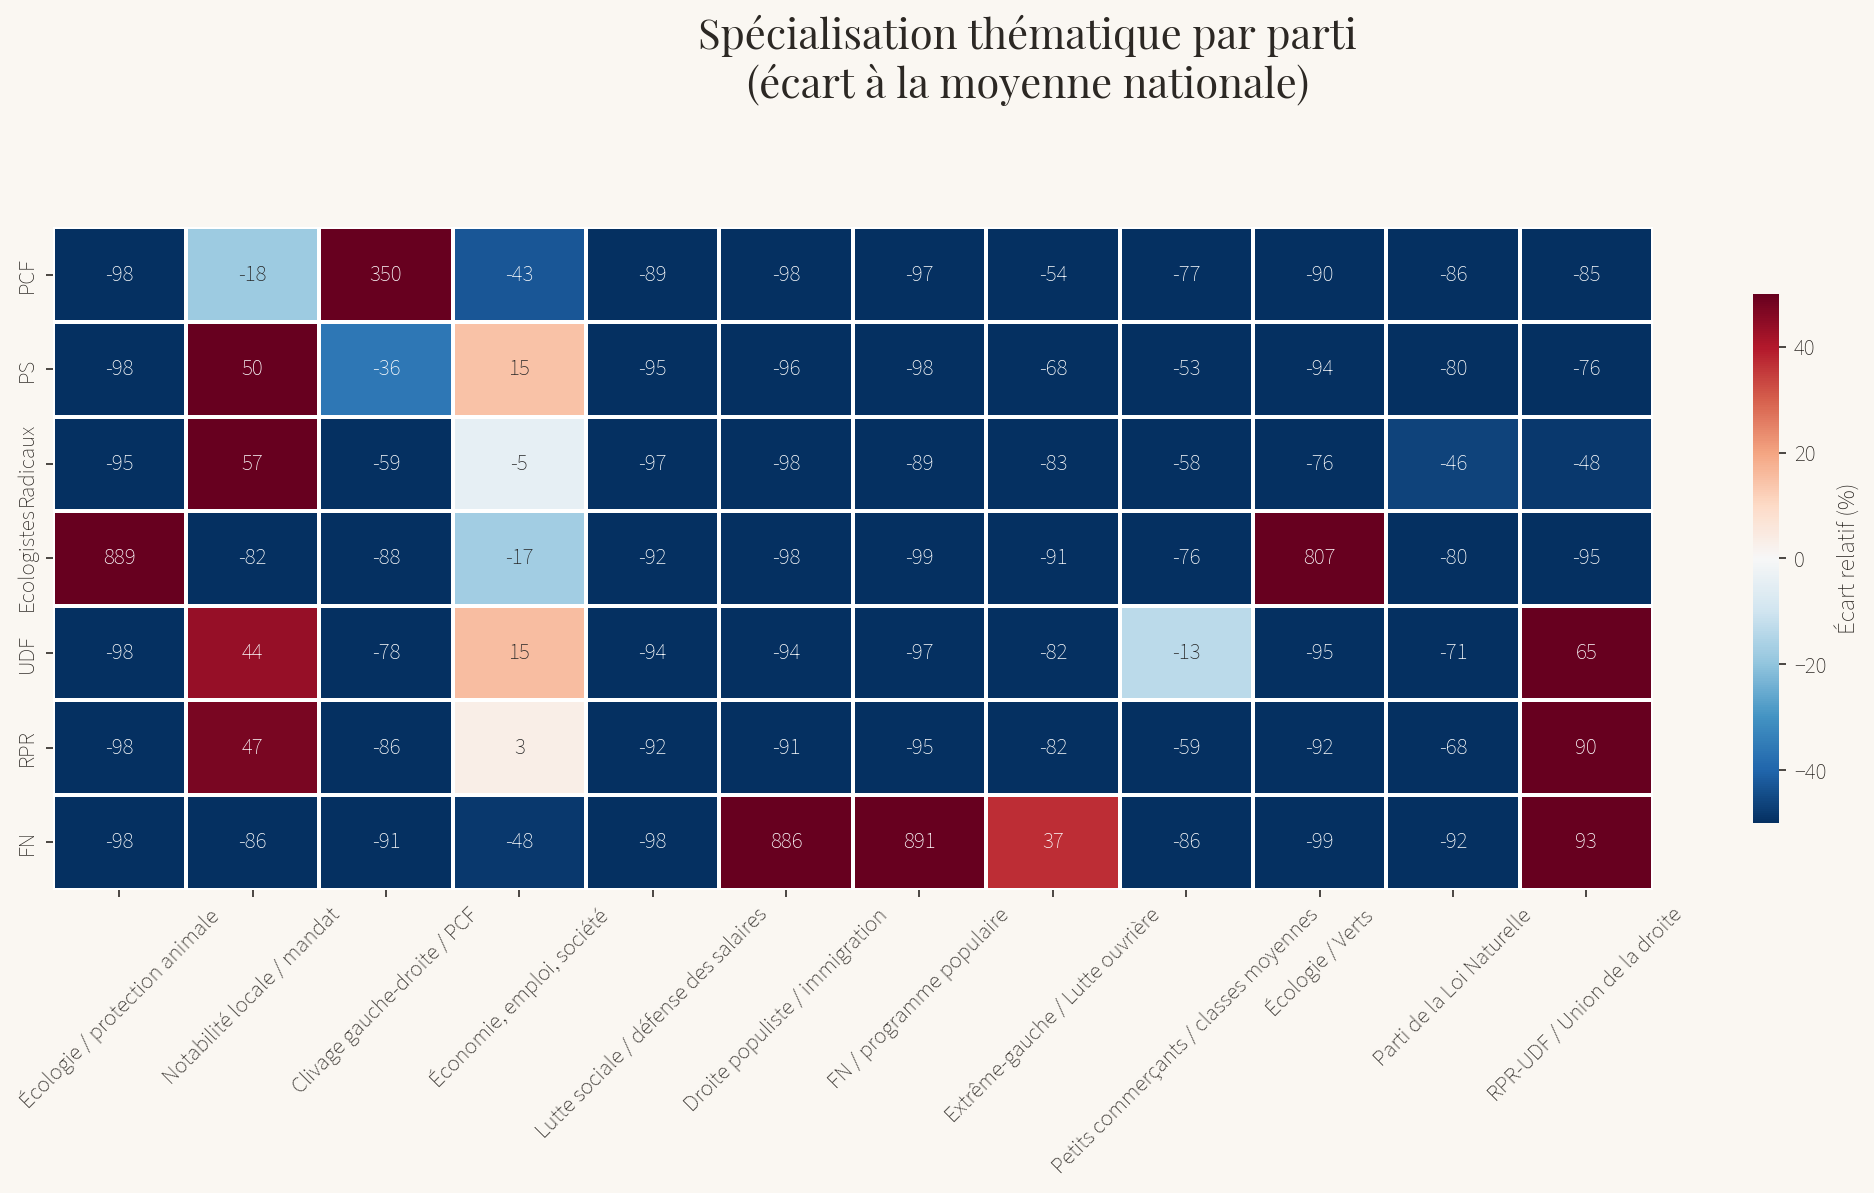

Calcul de la projection t-SNE...


TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

In [8]:
# =============================================================================
# 5. Figure 1 — Mots-clés de chaque topic (heatmap)
# =============================================================================
n_words_display = 10
topic_word_matrix = np.zeros((N_TOPICS, n_words_display))
all_top_words = []

for idx, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[-n_words_display:][::-1]
    for j, word_idx in enumerate(top_indices):
        topic_word_matrix[idx, j] = topic[word_idx]
    all_top_words.append([feature_names[i] for i in top_indices])

fig, ax = plt.subplots(figsize=(16, 8))
fig.suptitle("Mots-clés dominants par topic (LDA)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.97)

# Afficher les mots sous forme de tableau visuel
ax.set_xlim(0, n_words_display)
ax.set_ylim(-0.5, N_TOPICS - 0.5)
ax.invert_yaxis()

for i in range(N_TOPICS):
    weights = lda.components_[i]
    top_indices = weights.argsort()[-n_words_display:][::-1]
    max_w = weights[top_indices[0]]

    for j, word_idx in enumerate(top_indices):
        w = weights[word_idx]
        alpha = 0.3 + 0.7 * (w / max_w)
        ax.text(j + 0.5, i, feature_names[word_idx],
                ha='center', va='center', fontsize=9,
                fontfamily=FONT_BODY, fontweight='bold',
                color=TEXT_COLOR, alpha=alpha)

ax.set_yticks(range(N_TOPICS))
ax.set_yticklabels([TOPIC_NAMES.get(i, f"Topic {i}") for i in range(N_TOPICS)],
                    fontfamily=FONT_BODY, fontsize=11)
ax.set_xticks([])
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("../data/lda_topic_words.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

# =============================================================================
# 6. Assigner le topic dominant à chaque document
# =============================================================================
df_topic['topic_dominant'] = lda_topics.argmax(axis=1)
df_topic['topic_score'] = lda_topics.max(axis=1)

# Distribution des topics sur tout le corpus
for col in [f'topic_{i}' for i in range(N_TOPICS)]:
    topic_idx = int(col.split('_')[1])
    df_topic[col] = lda_topics[:, topic_idx]

print("\n=== Distribution des topics dominants ===")
print(df_topic['topic_dominant'].value_counts().sort_index())

# =============================================================================
# 7. Figure 2 — Distribution des topics par année
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Distribution thématique par année",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.98)

# Palette de couleurs pour les topics
topic_cmap = plt.cm.Set3
topic_colors = [topic_cmap(i / N_TOPICS) for i in range(N_TOPICS)]

for idx, year in enumerate(sorted(df_topic['year'].unique())):
    ax = axes[idx]
    year_data = df_topic[df_topic['year'] == year]

    # Moyenne des poids de chaque topic pour cette année
    topic_means = year_data[[f'topic_{i}' for i in range(N_TOPICS)]].mean()
    topic_means = topic_means.sort_values(ascending=True)

    topics_sorted = [int(t.split('_')[1]) for t in topic_means.index]
    labels = [TOPIC_NAMES.get(t, f"Topic {t}") for t in topics_sorted]
    colors = [topic_colors[t] for t in topics_sorted]

    bars = ax.barh(range(N_TOPICS), topic_means.values, height=0.65,
                   color=colors, edgecolor='white', linewidth=1)

    ax.set_yticks(range(N_TOPICS))
    ax.set_yticklabels(labels, fontsize=9, fontfamily=FONT_BODY)
    ax.set_title(year, fontfamily=FONT_TITLE, fontsize=18, fontweight='bold',
                 color=YEAR_COLORS.get(year, TEXT_COLOR), pad=12)
    ax.set_xlabel("Poids moyen du topic", fontsize=10)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/topics_par_annee.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

# =============================================================================
# 8. Figure 3 — Heatmap topics × partis politiques
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Propension thématique par famille politique",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.97)

# Calculer le poids moyen de chaque topic par parti
main_parties = ['PCF', 'PS', 'Radicaux', 'Ecologistes', 'UDF', 'RPR', 'FN']
df_main = df_topic[df_topic['parti_famille'].isin(main_parties)]

topic_party = df_main.groupby('parti_famille')[[f'topic_{i}' for i in range(N_TOPICS)]].mean()
topic_party.columns = [TOPIC_NAMES.get(i, f"Topic {i}") for i in range(N_TOPICS)]

# Réordonner les partis de gauche à droite
party_order = [p for p in main_parties if p in topic_party.index]
topic_party = topic_party.loc[party_order]

sns.heatmap(topic_party, cmap='YlOrRd', annot=True, fmt='.3f',
            linewidths=1, linecolor='white', ax=ax,
            cbar_kws={'label': 'Poids moyen du topic', 'shrink': 0.8})

ax.set_ylabel('')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/heatmap_topics_partis.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

# =============================================================================
# 9. Figure 4 — Spécialisation partisane (écart à la moyenne)
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Spécialisation thématique par parti\n(écart à la moyenne nationale)",
             fontfamily=FONT_TITLE, fontsize=20, fontweight='bold', y=0.99)

# Moyenne nationale pour chaque topic
national_mean = df_topic[[f'topic_{i}' for i in range(N_TOPICS)]].mean()

# Écart relatif par parti
specialization = topic_party.copy()
for col_idx, col in enumerate(specialization.columns):
    specialization[col] = (specialization[col] - national_mean.iloc[col_idx]) / national_mean.iloc[col_idx] * 100

sns.heatmap(specialization, cmap='RdBu_r', center=0, annot=True, fmt='.0f',
            linewidths=1, linecolor='white', ax=ax,
            vmin=-50, vmax=50,
            cbar_kws={'label': 'Écart relatif (%)', 'shrink': 0.8})

ax.set_ylabel('')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/specialisation_partis.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

# =============================================================================
# 10. Figure 5 — Projection 2D des candidats dans l'espace thématique
# =============================================================================
from sklearn.manifold import TSNE

print("Calcul de la projection t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
topics_2d = tsne.fit_transform(lda_topics)

df_topic['tsne_x'] = topics_2d[:, 0]
df_topic['tsne_y'] = topics_2d[:, 1]

# Par parti politique
fig, ax = plt.subplots(figsize=(14, 10))
fig.suptitle("Carte sémantique des professions de foi\n(projection t-SNE dans l'espace thématique)",
             fontfamily=FONT_TITLE, fontsize=20, fontweight='bold', y=0.97)

for party in main_parties:
    mask = df_topic['parti_famille'] == party
    ax.scatter(df_topic.loc[mask, 'tsne_x'], df_topic.loc[mask, 'tsne_y'],
               c=PARTY_COLORS.get(party, '#A89F96'), label=party,
               alpha=0.4, s=15, edgecolors='none')

ax.legend(frameon=False, fontsize=11, markerscale=3,
          title="Famille politique",
          title_fontproperties={'weight': 'bold', 'size': 12})
ax.set_xlabel("t-SNE 1", fontsize=12)
ax.set_ylabel("t-SNE 2", fontsize=12)
ax.grid(alpha=0.2)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/tsne_partis.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

# Par année
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Carte sémantique par année",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.98)

for idx, year in enumerate(sorted(df_topic['year'].unique())):
    ax = axes[idx]
    mask = df_topic['year'] == year

    for party in main_parties:
        party_mask = mask & (df_topic['parti_famille'] == party)
        ax.scatter(df_topic.loc[party_mask, 'tsne_x'],
                   df_topic.loc[party_mask, 'tsne_y'],
                   c=PARTY_COLORS.get(party, '#A89F96'),
                   alpha=0.4, s=12, edgecolors='none', label=party)

    ax.set_title(year, fontfamily=FONT_TITLE, fontsize=18, fontweight='bold',
                 color=YEAR_COLORS.get(year, TEXT_COLOR))
    ax.grid(alpha=0.2)
    ax.set_xticks([])
    ax.set_yticks([])

# Légende unique
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(main_parties),
           frameon=False, fontsize=10, markerscale=3,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/tsne_par_annee.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

# =============================================================================
# 11. Méthode 2 — NMF (Non-negative Matrix Factorization)
# =============================================================================
from sklearn.decomposition import NMF

# NMF fonctionne avec TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=10,
    max_df=0.7,
    stop_words=STOPWORDS_FR,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df_topic['text_clean'])
tfidf_features = tfidf_vectorizer.get_feature_names_out()

nmf = NMF(n_components=N_TOPICS, random_state=42, max_iter=500)
nmf_topics = nmf.fit_transform(tfidf_matrix)

print("\n=== Topics NMF ===\n")
nmf_topic_words = get_topic_words(nmf, tfidf_features)
for topic_id, words in nmf_topic_words.items():
    print(f"Topic {topic_id:2d} : {', '.join(words[:10])}")

# =============================================================================
# 12. Comparaison LDA vs NMF
# =============================================================================
fig, axes = plt.subplots(2, 1, figsize=(16, 14))
fig.suptitle("Comparaison LDA vs NMF — Mots-clés par topic",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.97)

for model_idx, (model_name, model_obj, features) in enumerate([
    ("LDA", lda, feature_names),
    ("NMF", nmf, tfidf_features)
]):
    ax = axes[model_idx]
    ax.set_xlim(0, n_words_display)
    ax.set_ylim(-0.5, N_TOPICS - 0.5)
    ax.invert_yaxis()

    for i in range(N_TOPICS):
        weights = model_obj.components_[i]
        top_indices = weights.argsort()[-n_words_display:][::-1]
        max_w = weights[top_indices[0]]

        for j, word_idx in enumerate(top_indices):
            w = weights[word_idx]
            alpha = 0.3 + 0.7 * (w / max_w)
            ax.text(j + 0.5, i, features[word_idx],
                    ha='center', va='center', fontsize=8,
                    fontfamily=FONT_BODY, fontweight='bold',
                    color=TEXT_COLOR, alpha=alpha)

    ax.set_yticks(range(N_TOPICS))
    ax.set_yticklabels([f"Topic {i}" for i in range(N_TOPICS)], fontsize=10)
    ax.set_xticks([])
    ax.set_title(model_name, fontfamily=FONT_TITLE, fontsize=16,
                 fontweight='bold', pad=10)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("../data/comparaison_lda_nmf.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

# =============================================================================
# 13. Évolution temporelle des topics (line chart)
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Évolution temporelle des thèmes dominants (LDA)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.97)

# Poids moyen de chaque topic par année
topic_evolution = df_topic.groupby('year')[[f'topic_{i}' for i in range(N_TOPICS)]].mean()

for i in range(N_TOPICS):
    col = f'topic_{i}'
    label = TOPIC_NAMES.get(i, f"Topic {i}")
    ax.plot(topic_evolution.index, topic_evolution[col],
            marker='o', markersize=8, linewidth=2.5,
            color=topic_colors[i], label=label, alpha=0.85)

ax.set_xlabel("Année", fontsize=13, fontfamily=FONT_BODY)
ax.set_ylabel("Poids moyen du topic", fontsize=13, fontfamily=FONT_BODY)
ax.grid(axis='y', alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False,
          fontsize=9, title="Thèmes",
          title_fontproperties={'weight': 'bold', 'size': 11})

plt.tight_layout(rect=[0, 0, 0.82, 0.93])
plt.savefig("../data/evolution_topics.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

# =============================================================================
# 14. Choix du nombre optimal de topics (coherence-like score)
# =============================================================================
from sklearn.decomposition import LatentDirichletAllocation

range_topics = [5, 8, 10, 12, 15, 20]
perplexities = []
log_likelihoods = []

print("Test de différents nombres de topics...")
for n in range_topics:
    lda_test = LatentDirichletAllocation(
        n_components=n, max_iter=20, learning_method='online',
        random_state=42, n_jobs=-1
    )
    lda_test.fit(count_matrix)
    perplexities.append(lda_test.perplexity(count_matrix))
    log_likelihoods.append(lda_test.score(count_matrix))
    print(f"  n={n:2d}  perplexité={perplexities[-1]:.1f}  log-likelihood={log_likelihoods[-1]:.1f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Choix du nombre optimal de topics",
             fontfamily=FONT_TITLE, fontsize=20, fontweight='bold', y=1.0)

ax1.plot(range_topics, perplexities, 'o-', color='#D4626E', linewidth=2.5, markersize=8)
ax1.set_xlabel("Nombre de topics")
ax1.set_ylabel("Perplexité (↓ = mieux)")
ax1.set_title("Perplexité", fontfamily=FONT_TITLE, fontsize=14)
ax1.grid(alpha=0.3)

ax2.plot(range_topics, log_likelihoods, 'o-', color='#5B8DB8', linewidth=2.5, markersize=8)
ax2.set_xlabel("Nombre de topics")
ax2.set_ylabel("Log-likelihood (↑ = mieux)")
ax2.set_title("Log-likelihood", fontfamily=FONT_TITLE, fontsize=14)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../data/choix_n_topics.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

# =============================================================================
# 15. Sauvegarde
# =============================================================================

# Sauvegarder le DataFrame avec les topics
df_topic.to_pickle("../data/df_topics.pkl")

# Sauvegarder les modèles et vectorizers
import pickle

with open("../data/lda_model.pkl", "wb") as f:
    pickle.dump({
        'lda': lda,
        'nmf': nmf,
        'count_vectorizer': count_vectorizer,
        'tfidf_vectorizer': tfidf_vectorizer,
        'topic_names': TOPIC_NAMES,
        'N_TOPICS': N_TOPICS,
    }, f)

print(f"\n✓ DataFrame sauvegardé : {len(df_topic)} lignes avec {N_TOPICS} topics")
print(f"✓ Modèles sauvegardés dans ../data/lda_model.pkl")
print(f"\n⚠️  PROCHAINE ÉTAPE : Inspecte les topics ci-dessus et remplis TOPIC_NAMES")
print(f"    avec des noms descriptifs (ex: 'Économie', 'Éducation', 'Europe', ...)")
print(f"    puis relance les figures pour avoir des labels lisibles.")

DIAGNOSTIC : Le LDA capture des rhétoriques partisanes, pas des thèmes

Les topics actuels reflètent surtout QUI parle (FN, PCF, LO, Verts...)
plutôt que DE QUOI on parle (emploi, Europe, sécurité...).

Cela s'explique par :
1. Le vocabulaire partisan très distinctif (noms de partis, slogans)
2. Les formules rituelles propres à chaque mouvement
3. La structure répétitive des professions de foi

→ Solution : supprimer le vocabulaire partisan des features

Matrice Count nettoyée : (12419, 3000)

=== Topics LDA AMÉLIORÉ ===

Topic  0 : travailleurs, majorité, gouvernement, alors, hommes, quelle, petits, opposer, intérêts, faveur, possible, fidèle
Topic  1 : suppression, ludf, faites, peine, famille, mort, peine mort, taxe, immigrés, drogue, mères, limmigration
Topic  2 : vie, société, temps, chômage, programme, monde, pays, travail, loi, citoyens, démocratie, nouvelle
Topic  3 : sociale, formation, développement, pays, solidarité, entreprises, sécurité, vie, jeunes, travail, personnes, éc

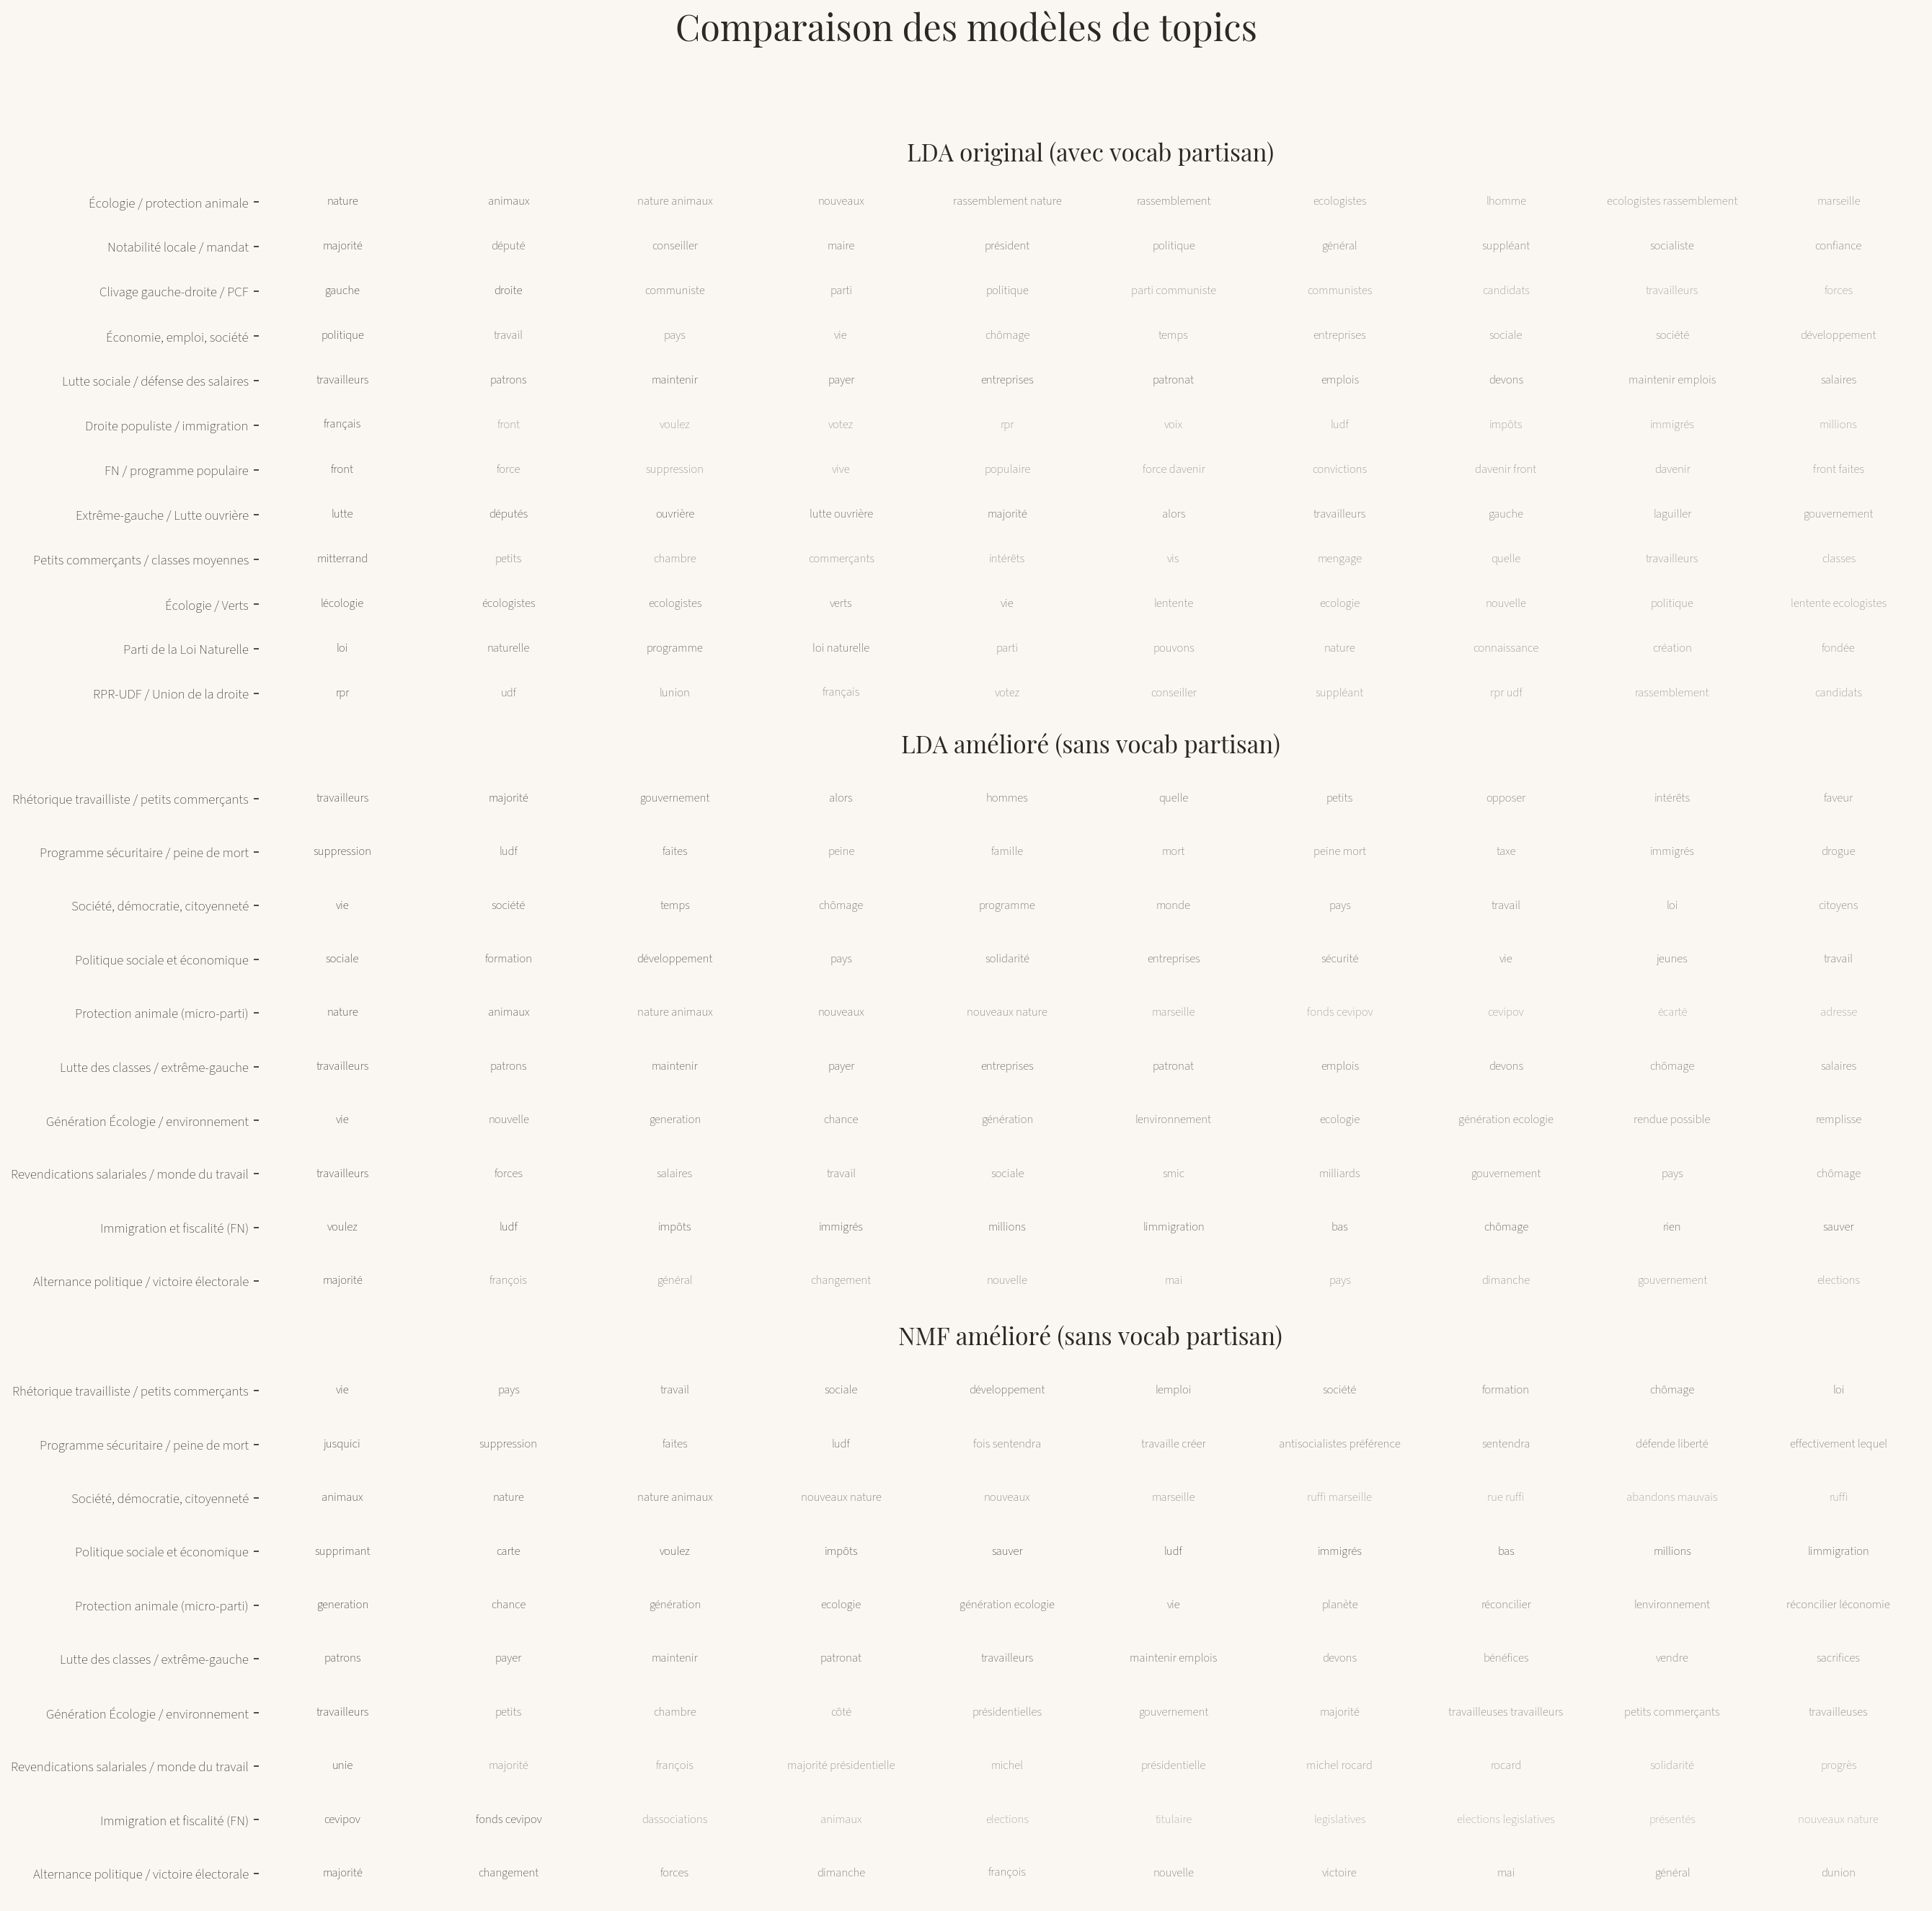


📖 LECTURE : Chaque ligne = un topic. Les mots sont classés par importance
   (opacité plus forte = poids plus élevé). Le LDA original capture surtout
   des identités partisanes. Le LDA amélioré, débarrassé du vocabulaire
   partisan, fait émerger de vrais thèmes de fond.



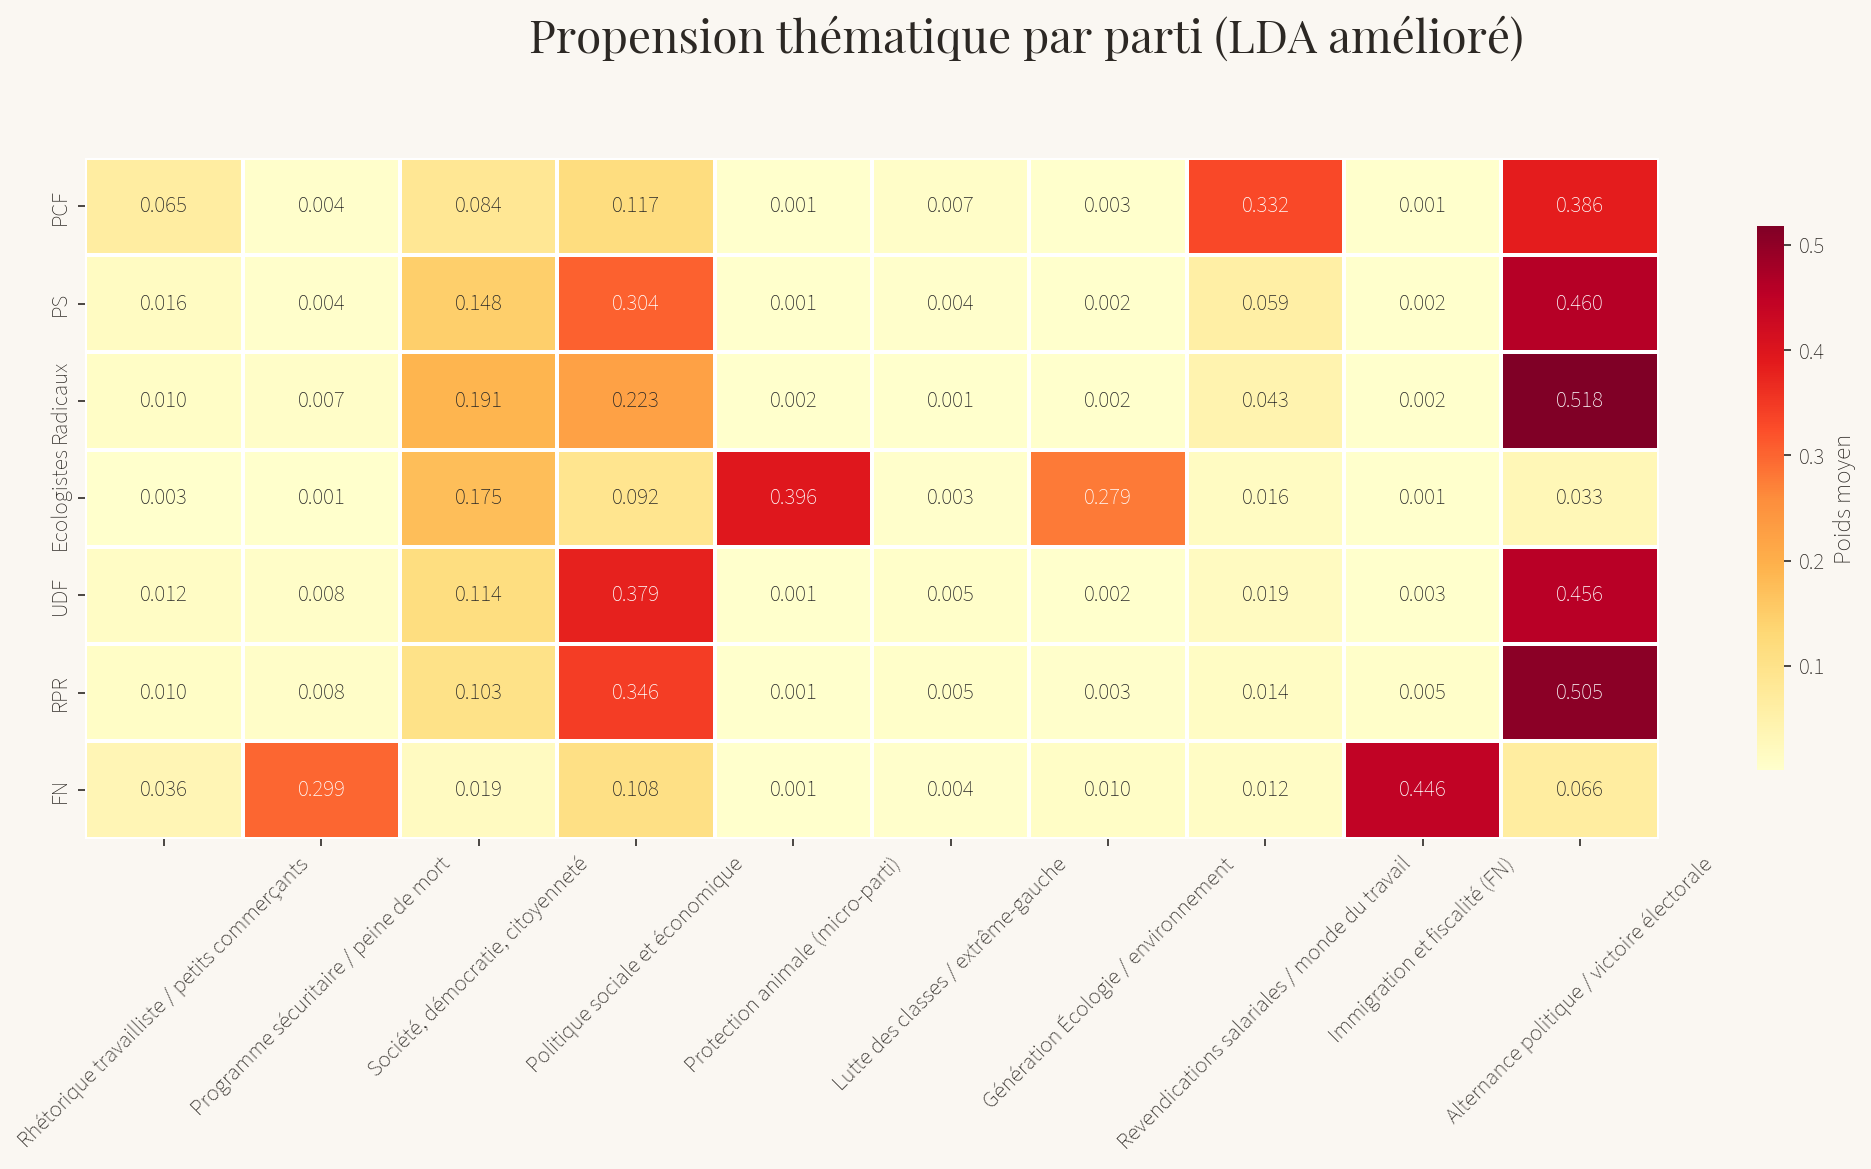


📖 LECTURE : Plus la case est foncée, plus le parti mobilise ce thème.
   Les partis sont ordonnés de gauche à droite sur l'échiquier politique.
   Exemple : si le PCF a un score élevé sur "Lutte des classes", cela signifie
   que ce thème est très présent dans les professions de foi communistes.



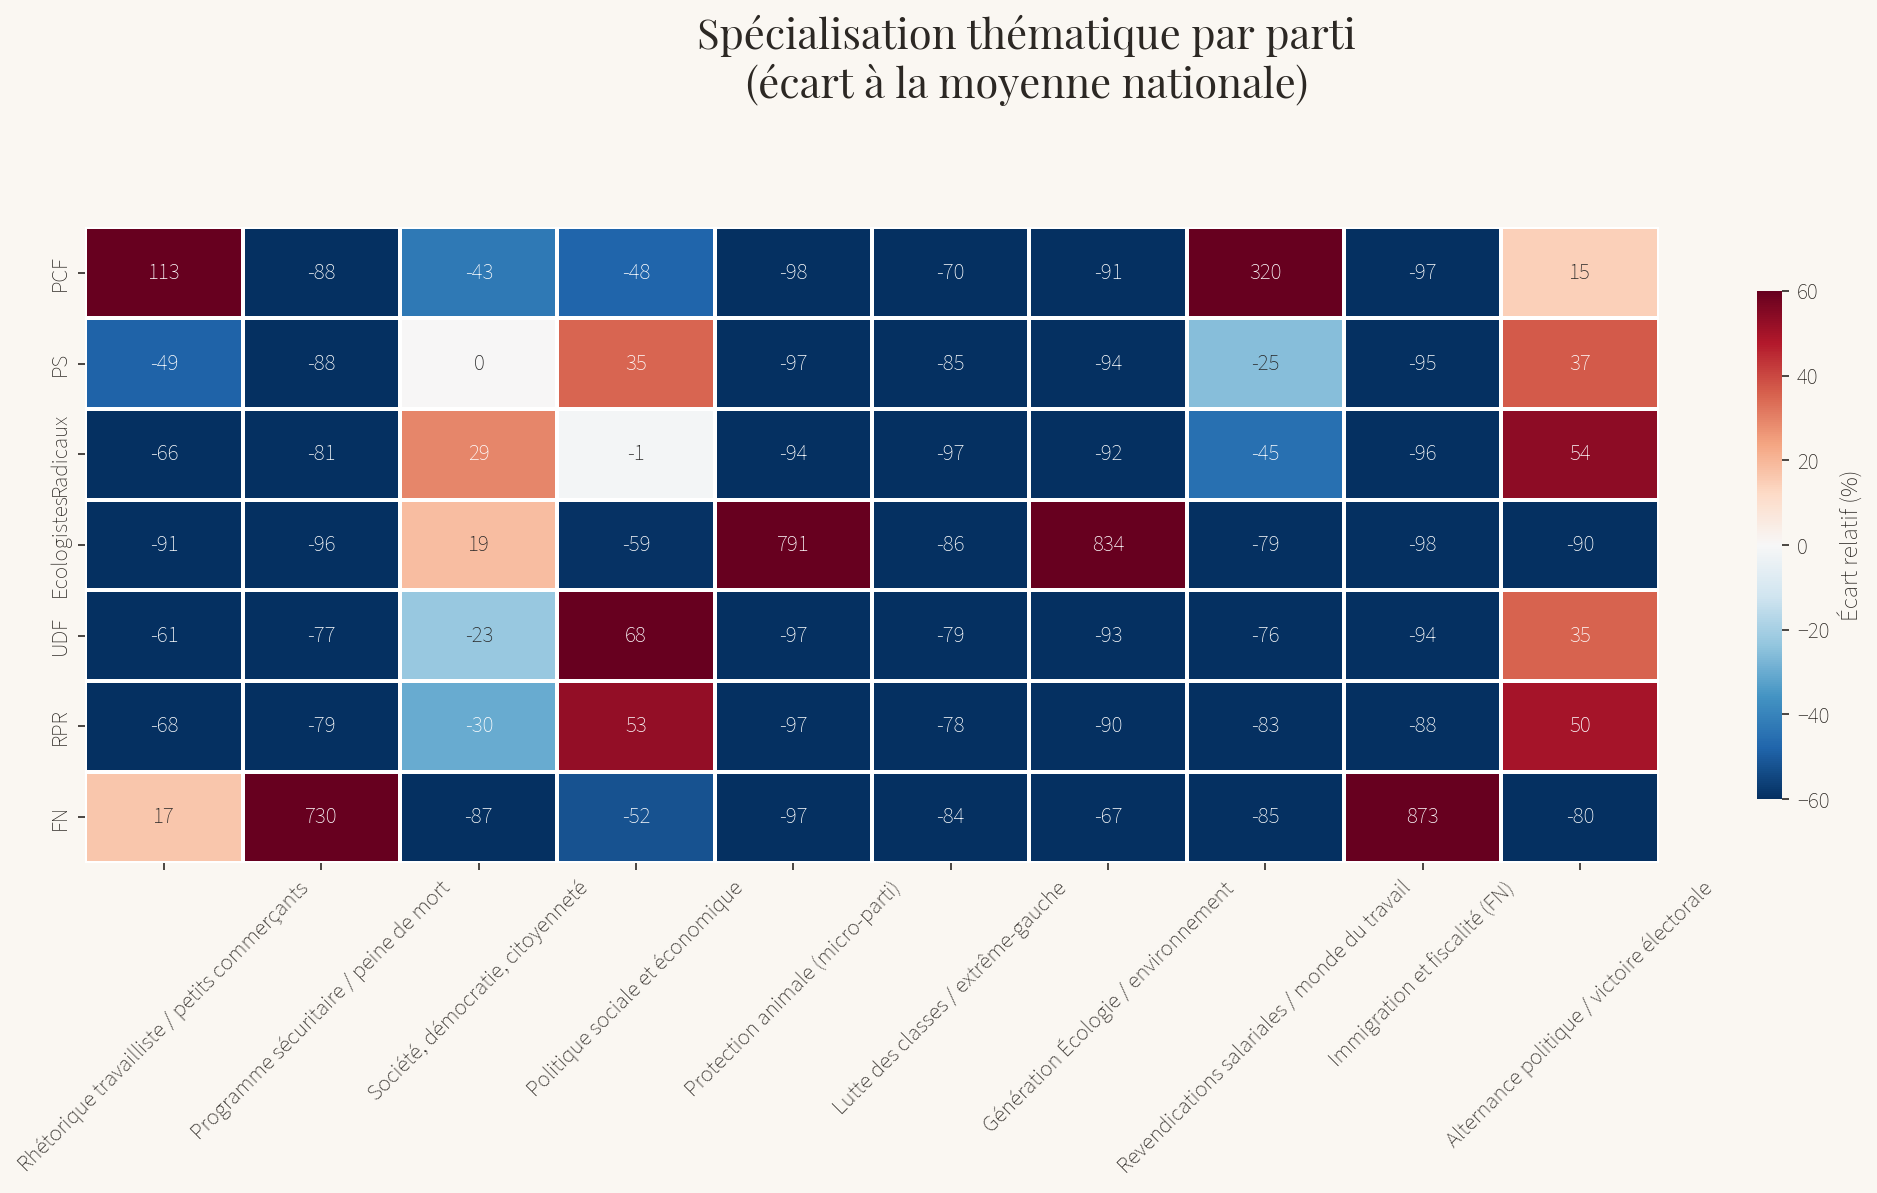


📖 LECTURE : Rouge = sur-représentation (le parti parle PLUS de ce thème
   que la moyenne nationale). Bleu = sous-représentation. Un score de +40%
   signifie que le parti mobilise ce thème 40% plus que la moyenne.
   Cela révèle la "spécialisation discursive" de chaque famille politique.



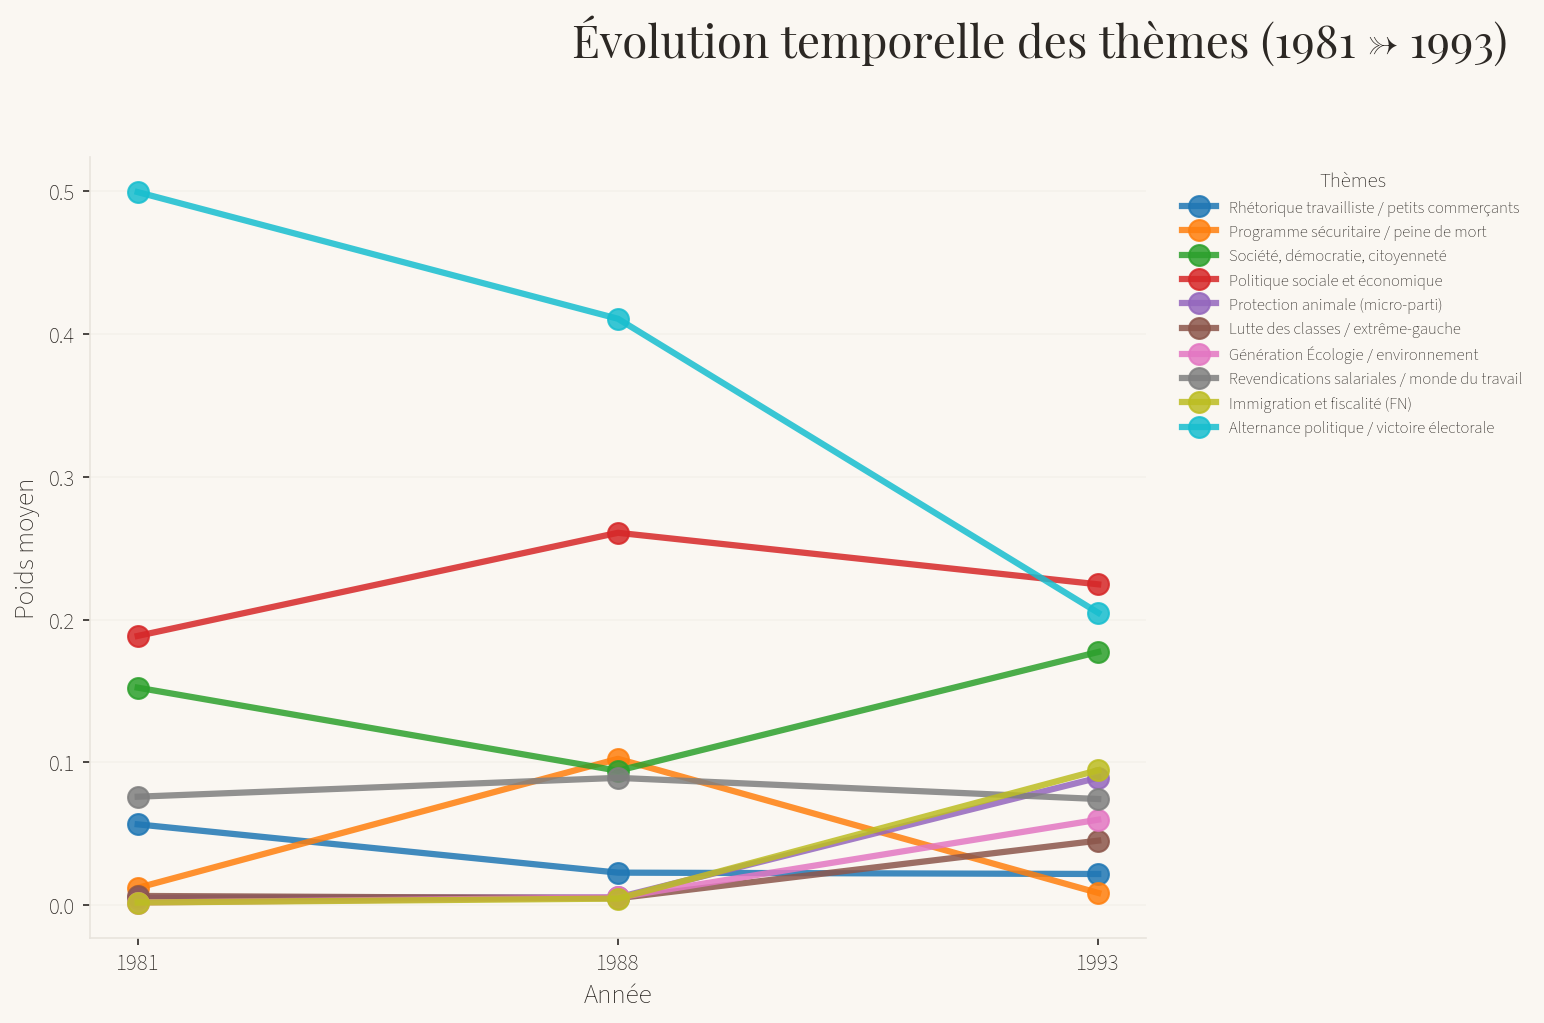


📖 LECTURE : Chaque courbe représente le poids moyen d'un thème dans les
   professions de foi de cette année. Une courbe montante = le thème prend
   de l'importance dans le discours politique. Les thèmes qui varient le plus
   entre 1981 et 1993 sont les plus intéressants pour l'analyse.

Calcul t-SNE sur topics améliorés...


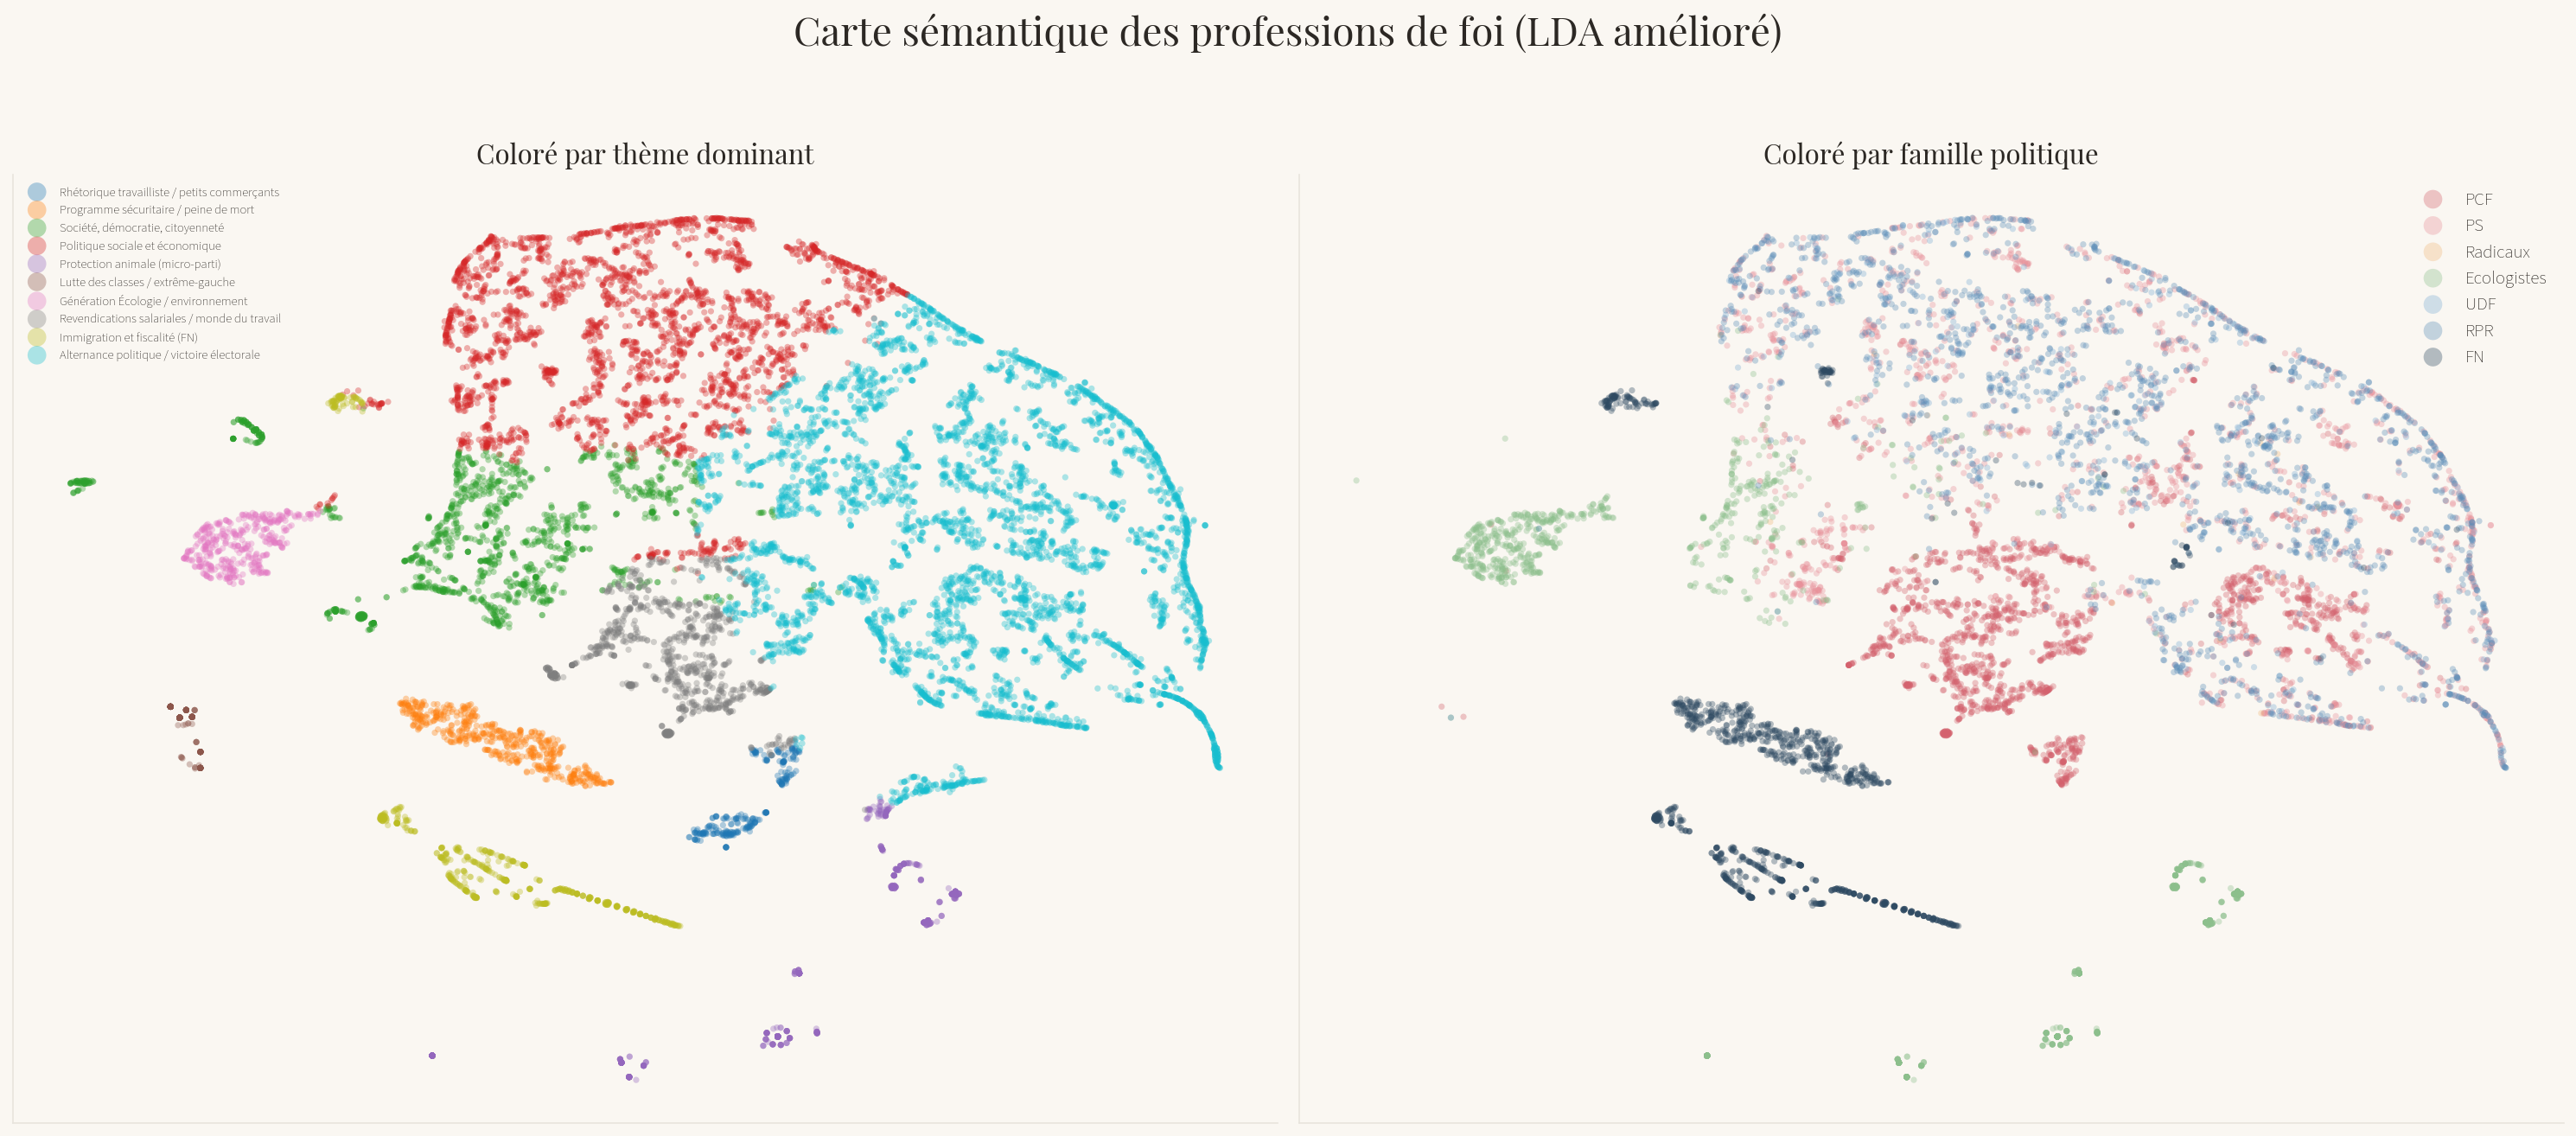


📖 LECTURE : Chaque point = une profession de foi. Les documents proches
   dans l'espace partagent des thèmes similaires. La carte de gauche montre
   les clusters thématiques, celle de droite montre la répartition des partis.
   En comparant les deux, on voit si les partis se regroupent par thème
   (= discours partisan homogène) ou s'éparpillent (= discours hétérogène).
   Un parti concentré dans une zone = discours très uniforme.
   Un parti dispersé = les candidats abordent des thèmes variés.



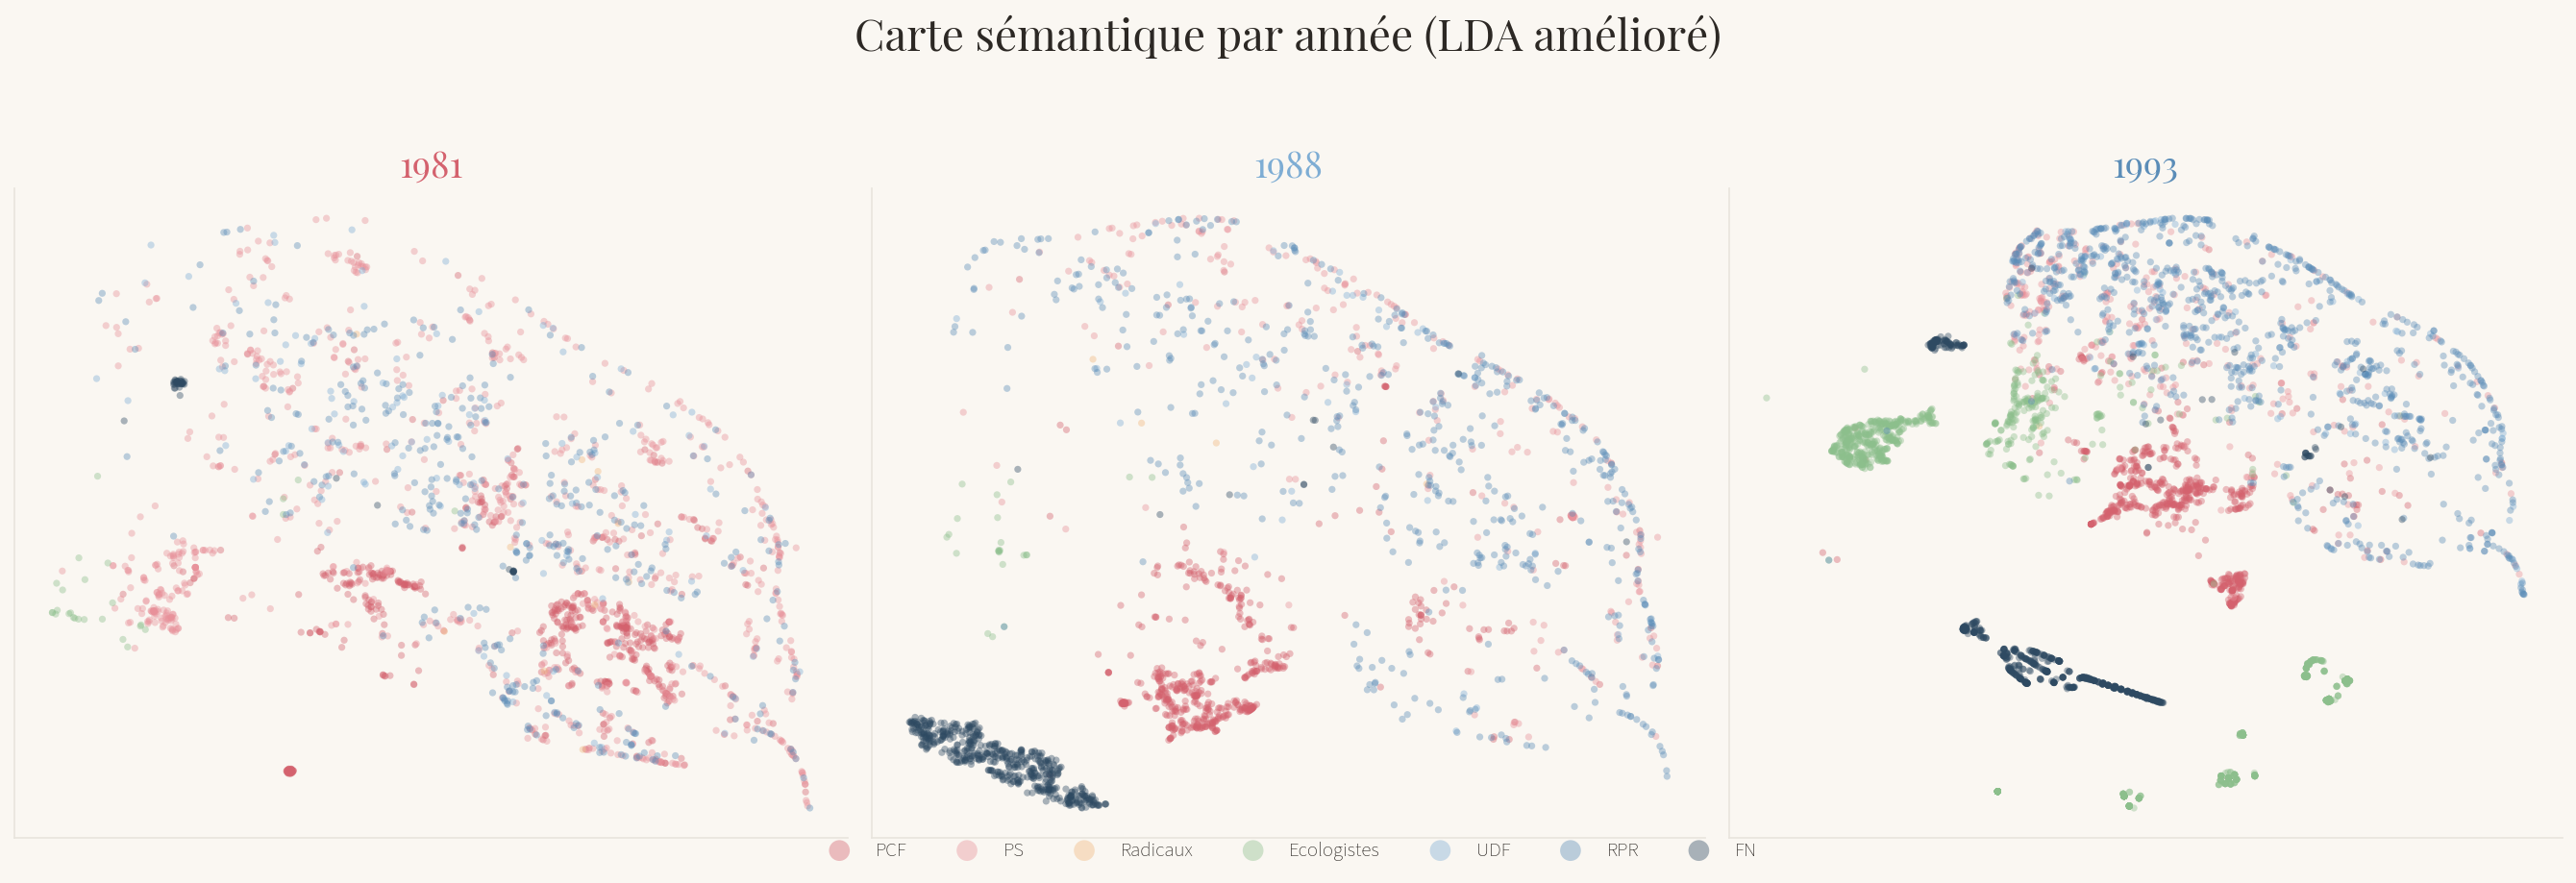


📖 LECTURE : La même projection t-SNE découpée par année. Permet de voir
   si la structure thématique du paysage politique change entre les élections.
   Des clusters qui se déplacent ou se fragmentent entre 1981 et 1993
   indiquent une évolution du discours politique.


=== Mots les plus EXCLUSIFS par topic ===
(mots qui distinguent le mieux chaque thème des autres)

  Topic  0 (Rhétorique travailliste / petits commerçants ) : opposer, pareil, nouveaux immigrés, sapprêtent, tienne, chômage limmigration, joint, damplifier
  Topic  1 (Programme sécuritaire / peine de mort        ) : suppression taxe, maternel, bureaucratique, assassins, priorité demploi, revenu maternel, effectivement, prononce
  Topic  2 (Société, démocratie, citoyenneté             ) : psu, technologies, pouvons accepter, lautogestion, lintolérance, criminalité, cohérente, initiative
  Topic  3 (Politique sociale et économique              ) : cohésion, vœu, préoccuper, loctroi, fatalité déclin, faiblesses, maintien

In [12]:
# =============================================================================
# NOTEBOOK 03 — TOPIC MODELING (PARTIE 2 : MODÈLE AMÉLIORÉ)
# =============================================================================
# Ce code s'exécute APRÈS la partie 1 (LDA original + TOPIC_NAMES)

# =============================================================================
# A. DIAGNOSTIC
# =============================================================================
print("=" * 70)
print("DIAGNOSTIC : Le LDA capture des rhétoriques partisanes, pas des thèmes")
print("=" * 70)
print("""
Les topics actuels reflètent surtout QUI parle (FN, PCF, LO, Verts...)
plutôt que DE QUOI on parle (emploi, Europe, sécurité...).

Cela s'explique par :
1. Le vocabulaire partisan très distinctif (noms de partis, slogans)
2. Les formules rituelles propres à chaque mouvement
3. La structure répétitive des professions de foi

→ Solution : supprimer le vocabulaire partisan des features
""")

# =============================================================================
# B. STOPWORDS PARTISAN (vocabulaire à supprimer)
# =============================================================================
STOPWORDS_PARTISAN = STOPWORDS_FR + [
    # Noms de partis et sigles
    'front', 'rpr', 'udf', 'pcf', 'rpf', 'fnr',
    'communiste', 'communistes', 'socialiste', 'socialistes',
    'gaulliste', 'gaullistes', 'écologiste', 'écologistes',
    'ecologiste', 'ecologistes', 'verts', 'vert',
    'radical', 'radicaux', 'centriste', 'centristes',
    'lutte', 'ouvrière', 'laguiller', 'arlette',
    'mitterrand', 'chirac', 'giscard', 'marchais', 'barre',
    'lepen', 'pen',
    # Vocabulaire électoral
    'parti', 'partis', 'mouvement', 'rassemblement', 'union',
    'coalition', 'alliance', 'entente', 'liste',
    'député', 'députés', 'suppléant', 'suppléante',
    'conseiller', 'conseillère', 'maire', 'président',
    'sénateur', 'assemblée', 'sénat', 'parlement',
    'candidat', 'candidate', 'candidats', 'candidates',
    'mandat', 'mandats', 'élu', 'élue', 'élus',
    'votez', 'voter', 'voix', 'bulletin', 'urne',
    'confiance', 'soutien', 'soutenir', 'appel',
    # Vocabulaire procédural
    'circonscription', 'arrondissement', 'canton',
    'scrutin', 'ballottage', 'tour',
    'madame', 'monsieur', 'mademoiselle', 'chers',
    'concitoyens', 'électeurs', 'électrices',
    'mengage', 'engage', 'promets',
    # Slogans et formules
    'vive', 'force', 'davenir', 'avenir',
    'convictions', 'populaire', 'ensemble',
    'république', 'française', 'france', 'français',
    'gauche', 'droite', 'centre',
    # Artefacts OCR
    'lécologie', 'lentente', 'lhomme', 'lunion',
    'lassemblée', 'quil', 'quils', 'quon', 'quelles',
    'cest', 'jai', 'dune', 'dun', 'nest', 'naura',
    'suis', 'jusquà', 'lorsque', 'puisque',
    # Micro-parti Loi Naturelle
    'naturelle', 'loi naturelle', 'connaissance',
    'transcendantale', 'méditation',
]

# =============================================================================
# C. LDA AMÉLIORÉ
# =============================================================================
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

N_TOPICS_CLEAN = 10

count_vec_clean = CountVectorizer(
    max_features=3000, min_df=15, max_df=0.6,
    stop_words=STOPWORDS_PARTISAN, ngram_range=(1, 2),
)
count_matrix_clean = count_vec_clean.fit_transform(df_topic['text_clean'])
feature_names_clean = count_vec_clean.get_feature_names_out()
print(f"Matrice Count nettoyée : {count_matrix_clean.shape}")

lda_clean = LatentDirichletAllocation(
    n_components=N_TOPICS_CLEAN, max_iter=50,
    learning_method='online', learning_decay=0.7,
    random_state=42, n_jobs=-1,
    doc_topic_prior=0.1, topic_word_prior=0.01,
)
lda_clean_topics = lda_clean.fit_transform(count_matrix_clean)

print(f"\n=== Topics LDA AMÉLIORÉ ===\n")
topic_words_clean = get_topic_words(lda_clean, feature_names_clean, n_words=12)
for topic_id, words in topic_words_clean.items():
    print(f"Topic {topic_id:2d} : {', '.join(words)}")

# =============================================================================
# D. NMF AMÉLIORÉ
# =============================================================================
tfidf_vec_clean = TfidfVectorizer(
    max_features=3000, min_df=15, max_df=0.6,
    stop_words=STOPWORDS_PARTISAN, ngram_range=(1, 2),
)
tfidf_matrix_clean = tfidf_vec_clean.fit_transform(df_topic['text_clean'])
tfidf_features_clean = tfidf_vec_clean.get_feature_names_out()

nmf_clean = NMF(n_components=N_TOPICS_CLEAN, random_state=42,
                max_iter=500, init='nndsvda')
nmf_clean_topics = nmf_clean.fit_transform(tfidf_matrix_clean)

print(f"\n=== Topics NMF AMÉLIORÉ ===\n")
nmf_topic_words_clean = get_topic_words(nmf_clean, tfidf_features_clean, n_words=12)
for topic_id, words in nmf_topic_words_clean.items():
    print(f"Topic {topic_id:2d} : {', '.join(words)}")

# =============================================================================
# E. NOMMAGE DES TOPICS
# =============================================================================
TOPIC_NAMES_CLEAN = {
    0: "Rhétorique travailliste / petits commerçants",
    1: "Programme sécuritaire / peine de mort",
    2: "Société, démocratie, citoyenneté",
    3: "Politique sociale et économique",
    4: "Protection animale (micro-parti)",
    5: "Lutte des classes / extrême-gauche",
    6: "Génération Écologie / environnement",
    7: "Revendications salariales / monde du travail",
    8: "Immigration et fiscalité (FN)",
    9: "Alternance politique / victoire électorale",
}

# Choix du meilleur modèle : LDA clean
best_topics = lda_clean_topics
best_n_topics = N_TOPICS_CLEAN
best_model = lda_clean
best_features = feature_names_clean

# Assigner au DataFrame
df_topic['topic_dominant_v2'] = best_topics.argmax(axis=1)
df_topic['topic_score_v2'] = best_topics.max(axis=1)
topic_cols_v2 = []
for i in range(best_n_topics):
    col = f'topic_v2_{i}'
    df_topic[col] = best_topics[:, i]
    topic_cols_v2.append(col)

print("\nDistribution des topics (LDA amélioré) :")
for t in range(best_n_topics):
    count = (df_topic['topic_dominant_v2'] == t).sum()
    name = TOPIC_NAMES_CLEAN.get(t, f"Topic {t}")
    print(f"  {t:2d}. {name:45s} : {count:5d} ({count/len(df_topic)*100:.1f}%)")

# =============================================================================
# F. Figure 1 — Comparaison des 3 modèles (mots-clés)
# =============================================================================
fig, axes = plt.subplots(3, 1, figsize=(18, 18))
fig.suptitle("Comparaison des modèles de topics",
             fontfamily=FONT_TITLE, fontsize=24, fontweight='bold', y=0.98)

n_words_display = 10
configs = [
    ("LDA original (avec vocab partisan)", lda, feature_names, N_TOPICS, TOPIC_NAMES),
    ("LDA amélioré (sans vocab partisan)", lda_clean, feature_names_clean, N_TOPICS_CLEAN, TOPIC_NAMES_CLEAN),
    ("NMF amélioré (sans vocab partisan)", nmf_clean, tfidf_features_clean, N_TOPICS_CLEAN, TOPIC_NAMES_CLEAN),
]

for model_idx, (title, model_obj, features, n_top, names) in enumerate(configs):
    ax = axes[model_idx]
    ax.set_xlim(0, n_words_display)
    ax.set_ylim(-0.5, n_top - 0.5)
    ax.invert_yaxis()

    for i in range(n_top):
        weights = model_obj.components_[i]
        top_indices = weights.argsort()[-n_words_display:][::-1]
        max_w = weights[top_indices[0]]

        for j, word_idx in enumerate(top_indices):
            w = weights[word_idx]
            alpha_val = max(0.0, min(1.0, 0.3 + 0.7 * (w / max_w) if max_w > 0 else 0.3))
            ax.text(j + 0.5, i, features[word_idx],
                    ha='center', va='center', fontsize=8,
                    fontfamily=FONT_BODY, fontweight='bold',
                    color=TEXT_COLOR, alpha=alpha_val)

    ax.set_yticks(range(n_top))
    ax.set_yticklabels([names.get(i, f"Topic {i}") for i in range(n_top)], fontsize=9)
    ax.set_xticks([])
    ax.set_title(title, fontfamily=FONT_TITLE, fontsize=16, fontweight='bold', pad=12)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../data/comparaison_3_modeles.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

print("""
📖 LECTURE : Chaque ligne = un topic. Les mots sont classés par importance
   (opacité plus forte = poids plus élevé). Le LDA original capture surtout
   des identités partisanes. Le LDA amélioré, débarrassé du vocabulaire
   partisan, fait émerger de vrais thèmes de fond.
""")

# =============================================================================
# G. Figure 2 — Heatmap topics × partis
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Propension thématique par parti (LDA amélioré)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.97)

main_parties = ['PCF', 'PS', 'Radicaux', 'Ecologistes', 'UDF', 'RPR', 'FN']
df_main = df_topic[df_topic['parti_famille'].isin(main_parties)]

topic_party_v2 = df_main.groupby('parti_famille')[topic_cols_v2].mean()
topic_party_v2.columns = [TOPIC_NAMES_CLEAN.get(i, f"Topic {i}") for i in range(best_n_topics)]
party_order = [p for p in main_parties if p in topic_party_v2.index]
topic_party_v2 = topic_party_v2.loc[party_order]

sns.heatmap(topic_party_v2, cmap='YlOrRd', annot=True, fmt='.3f',
            linewidths=1, linecolor='white', ax=ax,
            cbar_kws={'label': 'Poids moyen', 'shrink': 0.8})
ax.set_ylabel(''); ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/heatmap_topics_v2.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

print("""
📖 LECTURE : Plus la case est foncée, plus le parti mobilise ce thème.
   Les partis sont ordonnés de gauche à droite sur l'échiquier politique.
   Exemple : si le PCF a un score élevé sur "Lutte des classes", cela signifie
   que ce thème est très présent dans les professions de foi communistes.
""")

# =============================================================================
# H. Figure 3 — Spécialisation partisane (écart à la moyenne)
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Spécialisation thématique par parti\n(écart à la moyenne nationale)",
             fontfamily=FONT_TITLE, fontsize=20, fontweight='bold', y=0.99)

national_mean_v2 = df_topic[topic_cols_v2].mean()
spec_v2 = topic_party_v2.copy()
for col_idx, col in enumerate(spec_v2.columns):
    nat_val = national_mean_v2.iloc[col_idx]
    spec_v2[col] = ((spec_v2[col] - nat_val) / nat_val * 100) if nat_val > 0 else 0

sns.heatmap(spec_v2, cmap='RdBu_r', center=0, annot=True, fmt='.0f',
            linewidths=1, linecolor='white', ax=ax, vmin=-60, vmax=60,
            cbar_kws={'label': 'Écart relatif (%)', 'shrink': 0.8})
ax.set_ylabel(''); ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/specialisation_v2.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

print("""
📖 LECTURE : Rouge = sur-représentation (le parti parle PLUS de ce thème
   que la moyenne nationale). Bleu = sous-représentation. Un score de +40%
   signifie que le parti mobilise ce thème 40% plus que la moyenne.
   Cela révèle la "spécialisation discursive" de chaque famille politique.
""")

# =============================================================================
# I. Figure 4 — Évolution temporelle des thèmes
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Évolution temporelle des thèmes (1981 → 1993)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.97)

topic_evo_v2 = df_topic.groupby('year')[topic_cols_v2].mean()
topic_cmap_v2 = plt.cm.tab10

for i in range(best_n_topics):
    col = f'topic_v2_{i}'
    label = TOPIC_NAMES_CLEAN.get(i, f"Topic {i}")
    color = topic_cmap_v2(i / best_n_topics)
    ax.plot(topic_evo_v2.index, topic_evo_v2[col],
            marker='o', markersize=10, linewidth=3,
            color=color, label=label, alpha=0.85)

ax.set_xlabel("Année", fontsize=13)
ax.set_ylabel("Poids moyen", fontsize=13)
ax.grid(axis='y', alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=8,
          title="Thèmes", title_fontproperties={'weight': 'bold', 'size': 10})

plt.tight_layout(rect=[0, 0, 0.75, 0.93])
plt.savefig("../data/evolution_topics_v2.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

print("""
📖 LECTURE : Chaque courbe représente le poids moyen d'un thème dans les
   professions de foi de cette année. Une courbe montante = le thème prend
   de l'importance dans le discours politique. Les thèmes qui varient le plus
   entre 1981 et 1993 sont les plus intéressants pour l'analyse.
""")

# =============================================================================
# J. Figure 5 — Carte sémantique t-SNE (topics + partis)
# =============================================================================
from sklearn.manifold import TSNE

print("Calcul t-SNE sur topics améliorés...")
tsne_v2 = TSNE(n_components=2, random_state=42, perplexity=40, max_iter=1500)
topics_2d_v2 = tsne_v2.fit_transform(best_topics)

df_topic['tsne_v2_x'] = topics_2d_v2[:, 0]
df_topic['tsne_v2_y'] = topics_2d_v2[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.suptitle("Carte sémantique des professions de foi (LDA amélioré)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.97)

# Gauche : par topic dominant
ax = axes[0]
for t in range(best_n_topics):
    mask = df_topic['topic_dominant_v2'] == t
    label = TOPIC_NAMES_CLEAN.get(t, f"Topic {t}")
    color = topic_cmap_v2(t / best_n_topics)
    ax.scatter(df_topic.loc[mask, 'tsne_v2_x'], df_topic.loc[mask, 'tsne_v2_y'],
               c=[color], label=label, alpha=0.35, s=12, edgecolors='none')

ax.legend(frameon=False, fontsize=7, markerscale=3, loc='upper left')
ax.set_title("Coloré par thème dominant", fontfamily=FONT_TITLE, fontsize=15)
ax.grid(alpha=0.15)
ax.set_xticks([]); ax.set_yticks([])

# Droite : par parti
ax = axes[1]
for party in main_parties:
    mask = df_topic['parti_famille'] == party
    ax.scatter(df_topic.loc[mask, 'tsne_v2_x'], df_topic.loc[mask, 'tsne_v2_y'],
               c=PARTY_COLORS.get(party, '#A89F96'), label=party,
               alpha=0.35, s=12, edgecolors='none')

ax.legend(frameon=False, fontsize=10, markerscale=3)
ax.set_title("Coloré par famille politique", fontfamily=FONT_TITLE, fontsize=15)
ax.grid(alpha=0.15)
ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/tsne_v2_topics_partis.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

print("""
📖 LECTURE : Chaque point = une profession de foi. Les documents proches
   dans l'espace partagent des thèmes similaires. La carte de gauche montre
   les clusters thématiques, celle de droite montre la répartition des partis.
   En comparant les deux, on voit si les partis se regroupent par thème
   (= discours partisan homogène) ou s'éparpillent (= discours hétérogène).
   Un parti concentré dans une zone = discours très uniforme.
   Un parti dispersé = les candidats abordent des thèmes variés.
""")

# =============================================================================
# K. Figure 6 — Carte sémantique par année
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Carte sémantique par année (LDA amélioré)",
             fontfamily=FONT_TITLE, fontsize=22, fontweight='bold', y=0.98)

for idx, year in enumerate(sorted(df_topic['year'].unique())):
    ax = axes[idx]
    mask = df_topic['year'] == year
    for party in main_parties:
        party_mask = mask & (df_topic['parti_famille'] == party)
        ax.scatter(df_topic.loc[party_mask, 'tsne_v2_x'],
                   df_topic.loc[party_mask, 'tsne_v2_y'],
                   c=PARTY_COLORS.get(party, '#A89F96'),
                   alpha=0.4, s=12, edgecolors='none', label=party)
    ax.set_title(year, fontfamily=FONT_TITLE, fontsize=18, fontweight='bold',
                 color=YEAR_COLORS.get(year, TEXT_COLOR))
    ax.grid(alpha=0.2)
    ax.set_xticks([]); ax.set_yticks([])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(main_parties),
           frameon=False, fontsize=10, markerscale=3, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../data/tsne_v2_par_annee.png", dpi=200, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

print("""
📖 LECTURE : La même projection t-SNE découpée par année. Permet de voir
   si la structure thématique du paysage politique change entre les élections.
   Des clusters qui se déplacent ou se fragmentent entre 1981 et 1993
   indiquent une évolution du discours politique.
""")

# =============================================================================
# L. Mots les plus exclusifs par topic
# =============================================================================
print("\n=== Mots les plus EXCLUSIFS par topic ===")
print("(mots qui distinguent le mieux chaque thème des autres)\n")

for t in range(best_n_topics):
    weights = best_model.components_[t]
    other_weights = np.mean(np.delete(best_model.components_, t, axis=0), axis=0)

    with np.errstate(divide='ignore', invalid='ignore'):
        exclusivity = np.where(other_weights > 0, weights / other_weights, 0)

    mask_min_weight = weights > np.percentile(weights, 90)
    exclusivity_filtered = exclusivity * mask_min_weight

    top_exclusive = exclusivity_filtered.argsort()[-8:][::-1]
    words = [best_features[i] for i in top_exclusive]

    topic_name = TOPIC_NAMES_CLEAN.get(t, f"Topic {t}")
    print(f"  Topic {t:2d} ({topic_name:45s}) : {', '.join(words)}")

# =============================================================================
# M. Sauvegarde finale
# =============================================================================
df_topic.to_pickle("../data/df_topics.pkl")

import pickle
with open("../data/models_topic.pkl", "wb") as f:
    pickle.dump({
        'lda_original': lda,
        'lda_clean': lda_clean,
        'nmf_clean': nmf_clean,
        'count_vectorizer_clean': count_vec_clean,
        'tfidf_vectorizer_clean': tfidf_vec_clean,
        'topic_names_original': TOPIC_NAMES,
        'topic_names_clean': TOPIC_NAMES_CLEAN,
        'N_TOPICS_ORIGINAL': N_TOPICS,
        'N_TOPICS_CLEAN': N_TOPICS_CLEAN,
    }, f)

print(f"\n✓ DataFrame sauvegardé : {len(df_topic)} lignes")
print(f"✓ Modèles sauvegardés dans ../data/models_topic.pkl")